# **BIG DATA IN BUSINESS AND MARKETING PROJECT**
## Elena Maggiore, Marco Rosato

The **goal** of this project is to build a **portfolio** starting from some assets, **allocate** a budget of $50000 to minimise risks, and then obtain a **projection of future returns** in a six years time period.

So, the following steps will be performed:

1. **Download of stocks data** from different market sectors groups using yfinance.
2. **Preprocessing** on the resulting dataset.
3. **Clustering** on the stock, testing different clustering methods and choosing the best one.
4. **Portfolio creation**, by picking the best company from each cluster.
5. **Marginal risk calculation** and subsequent fund distribution.
6. **Out-of-sample projection**, the estimated portfolio performance on the test set.
7. **Results evaluation**, comparing the portfolio's projected results with the benchmark.
8. **Comparison with the equal split situation**, observing how the results would vary if money were split equally between assets instead of trying and minimise the risk.
9. **Comparison with Daily-Weekly-Monthly return**, observing how the final return changes and how the weight and selected stocks change based on the **frequency of data used** (Daily, Weekly, Monthly).
10. **Strategy Comparison: Sortino Ratio vs. Calmar Ratio**, to identify the optimal asset selection metric on a monthly timeframe.

Before starting, we mount Google Drive and import the required libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

## 1. **Download of stocks data**

First, we establish the **time period** of our analysis.

1st of January, 2012 is chosen as **starting date** because the general market has recovered from the 2008 crisis, so its bias won't affect the analysis.
The **end date** is chosen to be the 31th of December, 2025. Since we are working on years, we took the last complete year that was available.

In [ ]:
START_DATE="2012-01-01"
END_DATE="2025-12-31"

We pick the companies that could be included in the portfolio, ensuring to represent a **broad range** of industries and market segments rather than focusing on a single sector.

The chosen firms operate in **technology**, **healthcare**, **financial services**, **energy**, **consumer goods**, **industrials**, **defense**, **entertainment**, **precious metals**, and **automotive**. We also consider sector-specific **exchange-traded funds** (ETFs).

In [ ]:
tickers = {

    # Technology
    "APPLE":"AAPL",
    "MICROSOFT":"MSFT",
    "ALPHABET":"GOOGL",
    "NVIDIA":"NVDA",
    "ADOBE":"ADBE",
    "AMAZON":"AMZN",
    "ASML":"ASML",            # European but listed in the U.S market
    "ORACLE": "ORCL",
    "SALESFORCE": "CRM",
    "BROADCOM": "AVGO",
    "INTEL": "INTC",
    "AMD": "AMD",
    "META": "META",

    # Healthcare
    "JOHNSON_JOHNSON":"JNJ",
    "UNITEDHEALTH":"UNH",
    "PFIZER":"PFE",
    "ABBOTT":"ABT",
    "MEDTRONIC":"MDT",
    "SANOFI":"SNY",           # European but listed in the U.S market
    "ELI_LILLY": "LLY",
    "MERCK": "MRK",
    "THERMO_FISHER": "TMO",

    # Financial Services
    "JPMORGAN_CHASE":"JPM",
    "GOLDMAN_SACHS":"GS",
    "MORGAN_STANLEY":"MS",
    "VISA":"V",
    "MASTERCARD":"MA",
    "BLACKROCK":"BLK",
    "BERKSHIRE_HATHAWAY": "BRK-B",
    "AMERICAN_EXPRESS": "AXP",
    "CHARLES_SCHWAB": "SCHW",

    # Energy
    "EXXON":"XOM",
    "CHEVRON":"CVX",
    "NEXTERA_ENERGY":"NEE",
    "DUKE_ENERGY":"DUK",
    "SCHLUMBERGER":"SLB",
    "CAMECO":"CCJ",
    "DIAMONDBACK_ENERGY":"FANG",
    "CONOCOPHILLIPS": "COP",
    "EOG_RESOURCES": "EOG",
    "OCCIDENTAL_PETROLEUM": "OXY",

    # Consumer goods
    "PROCTER_GAMBLE":"PG",
    "COCA_COLA":"KO",
    "PEPSICO":"PEP",
    "WALMART":"WMT",
    "COSTCO":"COST",
    "MCDONALDS":"MCD",
    "NIKE":"NKE",
    "COLGATE_PALMOLIVE": "CL",
    "MONDELEZ": "MDLZ",
    "ESTEE_LAUDER": "EL",

    # Industrials
    "BOEING":"BA",
    "CATERPILLAR":"CAT",
    "GENERAL ELECTRIC":"GE",
    "HONEYWELL":"HON",
    "DEERE": "DE",
    "UNION_PACIFIC": "UNP",
    "WASTE_MANAGEMENT": "WM",

    # Defense
    "LOCKHEED_MARTIN":"LMT",
    "NORTHROP_GRUMMAN":"NOC",
    "RTX":"RTX",
    "GENERAL_DYNAMICS": "GD",

    # Entertainment
    "DISNEY":"DIS",
    "NETFLIX":"NFLX",
    "LIVE_NATION":"LYV",
    "SPOTIFY":"SPOT",
    "COMCAST": "CMCSA",

    # Precious metals
    "SIGNET":"SIG",
    "NEWMONT_GOLD":"NEM",
    "BARRICK_GOLD":"GOLD",
    "FRANCO_NEVADA":"FNV",
    "PAN_AMERICAN_SILVER":"PAAS",
    "AGNICO_EAGLE": "AEM",
    "WHEATON_PRECIOUS_METALS": "WPM",
    "HECLA_MINING": "HL",

    # Exchange-Traded Tunds (ETF)
    "LONG_TREASURIES_ETF":"TLT",
    "MEDIUM_TREASURIES_ETF":"IEF",
    "GOLD_ETF":"GLD",
    "SILVER_ETF":"SLV",
    "OIL_ETF":"USO",
    "SEMICONDUCTORS_ETF":"SMH",
    "REAL_ESTATE_ETF":"VNQ",
    "MATERIAL_ETF":"XLB",

    # Automative/Car
    "FORD":"F",
    "GENERAL_MOTORS":"GM",
    "TESLA":"TSLA",
    "TOYOTA":"TM",
    "HONDA":"HMC",
    "NISSAN":"NSANY",
    "BMW":"BMWKY",
    "VOLKSWAGEN":"VWAGY"
}

We add a **benchmark**, the reference index that we will use for comparison: in this case, we chose the stock market index **Standard & Poor's 500**, which tracks the performance of approximately 500 of the largest publicly traded companies in the United States.


In [ ]:
BENCHMARK="^GSPC"

Through the following query, data is downloaded and saved in the *prices* dataframe. *yf.download()* returns a DataFrame with a multi-level column structure when multiple assets are requested, so in this situation the code extracts only the adjusted closing prices (*"Close"*).

Here we are using the daily average prices. It's possible to download prices weekly or even monthly by using the commented code in the cell below.

In [ ]:
#DAILY VERSION

all_assets=list(tickers.values())+[BENCHMARK]

raw_data_daily=yf.download(
    all_assets,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

if isinstance(raw_data_daily.columns, pd.MultiIndex):
    prices=raw_data_daily["Close"]
else:
  prices = raw_data_daily

[*********************100%***********************]  92 of 92 completed


Let's see a glimpse of the downloaded data, i.e. the closing prices of the first 20 days for each asset.

In [ ]:
prices.head(20)

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,...,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,12.310346,20.339449,28.570000,29.764469,5.48,8.9515,40.208763,2.062701,39.606853,60.731098,...,317.519989,23.196760,32.978210,8.783474,23.479212,15.094024,25.380899,12.813103,48.873951,1277.060059
2012-01-04,12.376502,20.260559,28.280001,29.165602,5.46,8.8755,39.646881,2.027076,39.631504,60.821098,...,318.160004,22.782322,32.414398,8.715719,23.128887,14.938903,25.297958,12.921027,48.885307,1277.300049
2012-01-05,12.513907,20.213945,28.480000,29.523363,5.46,8.8805,39.218315,2.029926,40.091564,60.166481,...,313.359985,22.953503,32.718861,8.845069,23.314781,14.866350,25.372608,12.958242,48.737564,1281.060059
2012-01-06,12.644724,20.031059,28.719999,29.367807,5.43,9.1305,38.961178,2.017101,39.656139,60.534714,...,313.760010,22.683228,32.611721,8.638726,23.586466,14.761271,24.966185,12.939632,48.373856,1277.810059
2012-01-09,12.624668,20.027470,28.530001,29.585575,5.59,8.9280,39.275448,2.153189,39.754738,60.984753,...,312.640015,22.500780,32.498959,8.709560,23.550707,14.806303,25.040831,12.965685,48.589802,1280.699951
2012-01-10,12.669873,20.120707,29.200001,29.756689,5.71,8.9670,39.542122,2.183827,39.984764,61.369343,...,314.720001,22.478258,32.859798,8.814273,23.893888,14.771277,25.729269,13.207583,48.714828,1292.079956
2012-01-11,12.649214,20.044754,29.320000,29.352261,5.81,8.9450,39.846874,2.223014,40.214790,61.156578,...,311.359985,22.322849,33.090969,8.952861,23.829546,14.861343,25.720974,13.337833,48.351097,1292.479980
2012-01-12,12.614492,19.950710,29.230000,29.126701,5.82,8.7965,39.751629,2.257215,40.789875,61.786652,...,304.480011,22.825123,32.848522,9.103769,24.187025,14.886364,25.961517,13.523911,48.157871,1295.500000
2012-01-13,12.567188,20.048370,28.969999,28.784500,5.66,8.9210,39.313553,2.249377,40.880245,61.042030,...,305.279999,22.689983,32.921833,8.885106,23.879591,14.896375,25.720974,13.434596,48.237446,1289.089966


Before proceding with preprocessing, we will plot trends for each group of assets.

First, we define the market segments:

In [ ]:
groups={
    "Technology": ["AAPL", "MSFT", "GOOGL", "NVDA", "ADBE", "AMZN", "ASML", "ORCL", "CRM", "AVGO", "INTC", "AMD", "META"],
    "Healthcare": ["JNJ", "UNH", "PFE", "ABT", "MDT", "SNY", "LLY", "MRK", "TMO"],
    "Financial services": ["JPM", "GS", "MS", "V", "MA", "BLK", "BRK-B", "AXP", "SCHW"],
    "Energy": ["XOM", "CVX", "NEE", "DUK", "SLB", "CCJ", "FANG", "COP", "EOG", "OXY"],
    "Consumer goods": ["PG", "KO", "PEP", "WMT", "COST", "MCD", "NKE", "CL", "MDLZ", "EL"],
    "Industrial": ["BA", "CAT", "GE", "HON", "DE", "UNP", "WM"],
    "Defense": ["LMT", "NOC", "RTX", "GD"],
    "Entertainement": ["DIS", "NFLX", "LYV", "SPOT", "CMCSA"],
    "Precious Metals": ["SIG", "NEM", "GOLD", "FNV", "PAAS", "AEM", "WPM", "HL"],
    "ETFs": ["TLT", "IEF", "GLD", "SLV", "USO", "SMH", "VNQ", "XLB"],
    "Automotive": ["F", "GM", "TSLA", "TM", "HMC", "NSANY", "BMWKY", "VWAGY"]
}

And create a plot for each market sector.

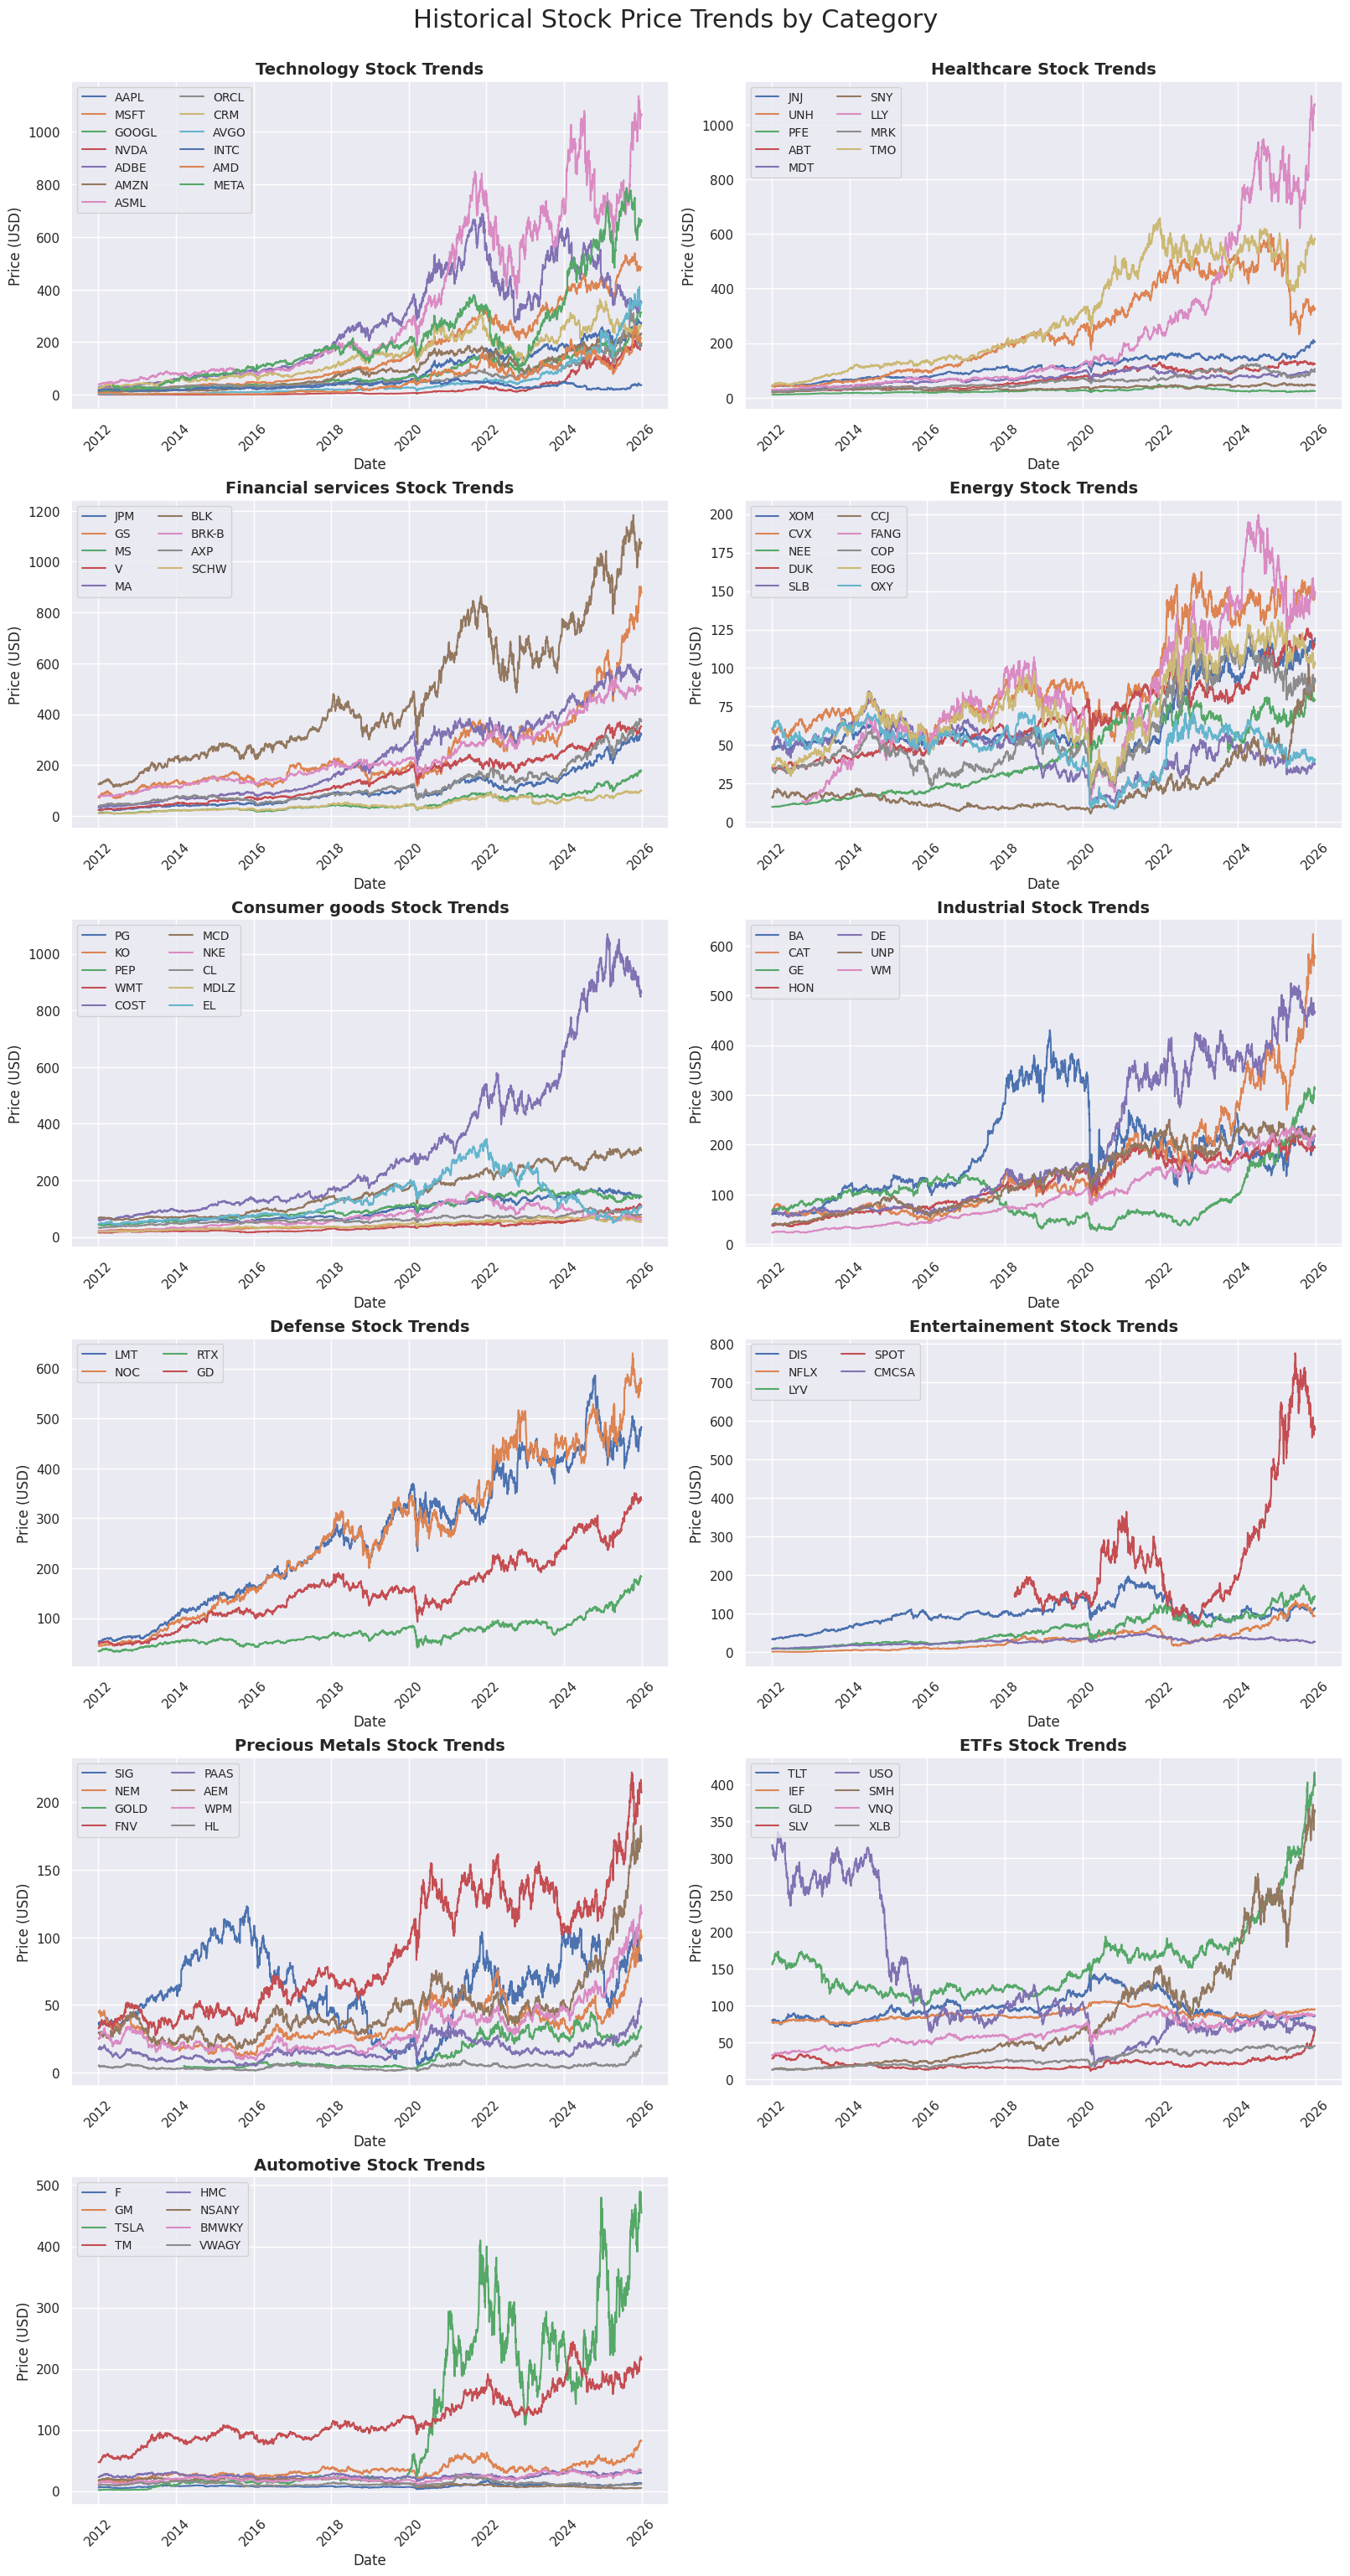

In [ ]:
sns.set_theme(style="darkgrid")

n_groups = len(groups)
cols = 2
rows = (n_groups + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (group_name, symbols) in enumerate(groups.items()):
    valid_symbols = [s for s in symbols if s in prices.columns]

    if not valid_symbols:
        axes[i].set_title(f"{group_name} (No Data)")
        continue

    for symbol in valid_symbols:
        axes[i].plot(prices.index, prices[symbol], label=symbol, linewidth=1.5)

    axes[i].set_title(f"{group_name} Stock Trends", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend(loc='upper left', fontsize='small', ncol=2)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Historical Stock Price Trends by Category", fontsize=22, y=1.02)
plt.show()

## 2. **Preprocessing**

First, let's see where we start from:

In [ ]:
print(len(prices))
print(len(prices.columns))

3519
92


92 stocks are considered, over a total of 3519 days.

In [ ]:
prices[prices.isna().any(axis=1)]

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,...,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,12.310346,20.339449,28.570000,29.764469,5.48,8.951500,40.208763,2.062701,39.606853,60.731098,...,317.519989,23.196760,32.978210,8.783474,23.479212,15.094024,25.380899,12.813103,48.873951,1277.060059
2012-01-04,12.376502,20.260559,28.280001,29.165602,5.46,8.875500,39.646881,2.027076,39.631504,60.821098,...,318.160004,22.782322,32.414398,8.715719,23.128887,14.938903,25.297958,12.921027,48.885307,1277.300049
2012-01-05,12.513907,20.213945,28.480000,29.523363,5.46,8.880500,39.218315,2.029926,40.091564,60.166481,...,313.359985,22.953503,32.718861,8.845069,23.314781,14.866350,25.372608,12.958242,48.737564,1281.060059
2012-01-06,12.644724,20.031059,28.719999,29.367807,5.43,9.130500,38.961178,2.017101,39.656139,60.534714,...,313.760010,22.683228,32.611721,8.638726,23.586466,14.761271,24.966185,12.939632,48.373856,1277.810059
2012-01-09,12.624668,20.027470,28.530001,29.585575,5.59,8.928000,39.275448,2.153189,39.754738,60.984753,...,312.640015,22.500780,32.498959,8.709560,23.550707,14.806303,25.040831,12.965685,48.589802,1280.699951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-26,40.550949,52.715710,228.910004,35.948524,10.44,77.792999,191.057419,19.819361,82.944160,315.053619,...,105.680000,113.861649,53.493912,12.206626,73.130089,25.712997,18.432280,24.210674,51.155540,2658.550049
2018-03-27,39.511185,52.033794,213.800003,35.558243,10.00,74.852501,184.463211,19.550545,81.869545,307.535706,...,104.639999,110.803680,53.697880,12.023380,72.399940,25.286900,18.279205,23.965057,50.948154,2612.620117
2018-03-28,39.074619,51.127422,212.539993,35.142502,9.81,71.570999,179.158371,18.935314,82.577019,306.482239,...,104.320000,110.416725,55.045609,11.897112,72.304291,25.792343,18.072092,23.660141,50.332901,2605.000000


The American market opens on January 3rd, while the European market opens on January 2nd. Because of this, the following code block is currently redundant for our primary data. However, if we would have decided to add stocks listed on other global exchanges, this alignment step becomes essential to synchronize the different trading calendars and remove mismatched dates.

In [ ]:
prices = prices.dropna(axis=1, how="all")
prices = prices.dropna(subset=[BENCHMARK])
prices

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,...,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,12.310346,20.339449,28.570000,29.764469,5.480000,8.951500,40.208763,2.062701,39.606853,60.731098,...,317.519989,23.196760,32.978210,8.783474,23.479212,15.094024,25.380899,12.813103,48.873951,1277.060059
2012-01-04,12.376502,20.260559,28.280001,29.165602,5.460000,8.875500,39.646881,2.027076,39.631504,60.821098,...,318.160004,22.782322,32.414398,8.715719,23.128887,14.938903,25.297958,12.921027,48.885307,1277.300049
2012-01-05,12.513907,20.213945,28.480000,29.523363,5.460000,8.880500,39.218315,2.029926,40.091564,60.166481,...,313.359985,22.953503,32.718861,8.845069,23.314781,14.866350,25.372608,12.958242,48.737564,1281.060059
2012-01-06,12.644724,20.031059,28.719999,29.367807,5.430000,9.130500,38.961178,2.017101,39.656139,60.534714,...,313.760010,22.683228,32.611721,8.638726,23.586466,14.761271,24.966185,12.939632,48.373856,1277.810059
2012-01-09,12.624668,20.027470,28.530001,29.585575,5.590000,8.928000,39.275448,2.153189,39.754738,60.984753,...,312.640015,22.500780,32.498959,8.709560,23.550707,14.806303,25.040831,12.965685,48.589802,1280.699951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,271.854919,123.139786,352.420013,180.501190,214.899994,232.139999,1058.130127,348.037933,380.141113,216.850006,...,70.300003,351.923218,86.485054,11.508325,218.520370,110.462059,122.502640,45.377769,117.829521,6909.790039
2025-12-24,273.302216,123.406746,352.980011,180.570892,215.039993,232.380005,1061.797241,348.934631,381.056152,218.160004,...,70.199997,353.675964,87.053909,11.508325,219.531967,111.169258,121.585464,45.467041,117.632195,6932.049805
2025-12-26,272.893005,123.436409,353.799988,182.432983,214.990005,232.520004,1069.001953,350.837616,379.007202,216.440002,...,68.480003,353.536560,87.151978,11.442563,219.274109,111.298744,123.838524,45.734844,117.523659,6929.939941


In case of the presence of missing values at random, we fill the missing value with the value of the day before. However, this won't solve problems such as data missing for longer periods of time.

In [ ]:
# Count NaN before fill
nan_count_before = prices.isna().sum().sum()

# Fill
prices = prices.ffill()

# Count NaN after fill
nan_count_after = prices.isna().sum().sum()

print(f"Total NaNs before .ffill(): {nan_count_before}")
print(f"Total NaNs after .ffill(): {nan_count_after}")

Total NaNs before .ffill(): 2415
Total NaNs after .ffill(): 2415


However, we still have NAs:

In [ ]:
print(prices.isna().sum().sum())
prices.loc[:,prices.isna().any(axis=0)]

2415


Ticker,FANG,GOLD,META,SPOT
Date,,,,
2012-01-03,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN
2012-01-09,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-12-23,146.474045,33.455502,663.755981,579.390015
2025-12-24,145.238266,34.496651,666.361389,586.570007
2025-12-26,144.645081,34.298336,662.108887,584.349976


As we can see, the NANs are located specifically on these four assets:

* FANG (DIAMONDBACK ENERGY)
* GOLD (BARRICK GOLD)
* META
* SPOT (SPOTIFY)

In [ ]:
target_tickers = ['FANG', 'GOLD', 'META', 'SPOT']

for ticker in target_tickers:
    if ticker in prices.columns:
        first_date = prices[ticker].first_valid_index()
        print(f"{ticker}: First available date is {first_date.date()}")
    else:
        print(f"{ticker}: Ticker not found in the DataFrame.")

FANG: First available date is 2012-10-12
GOLD: First available date is 2014-03-17
META: First available date is 2012-05-18
SPOT: First available date is 2018-04-03


By looking at company information, we know that they were all listed on the stock exchange after 2012-01-03.

To solve this problem, they're removed altogether.



In [ ]:
prices = prices.dropna(axis=1, how="any")
print(prices.isna().sum().sum())

0


Now, the dataset comprehends 3519 rows and 88 columns.

In [ ]:
prices

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,...,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,12.310346,20.339449,28.570000,29.764469,5.480000,8.951500,40.208763,2.062701,39.606853,60.731098,...,317.519989,23.196760,32.978210,8.783474,23.479212,15.094024,25.380899,12.813103,48.873951,1277.060059
2012-01-04,12.376502,20.260559,28.280001,29.165602,5.460000,8.875500,39.646881,2.027076,39.631504,60.821098,...,318.160004,22.782322,32.414398,8.715719,23.128887,14.938903,25.297958,12.921027,48.885307,1277.300049
2012-01-05,12.513907,20.213945,28.480000,29.523363,5.460000,8.880500,39.218315,2.029926,40.091564,60.166481,...,313.359985,22.953503,32.718861,8.845069,23.314781,14.866350,25.372608,12.958242,48.737564,1281.060059
2012-01-06,12.644724,20.031059,28.719999,29.367807,5.430000,9.130500,38.961178,2.017101,39.656139,60.534714,...,313.760010,22.683228,32.611721,8.638726,23.586466,14.761271,24.966185,12.939632,48.373856,1277.810059
2012-01-09,12.624668,20.027470,28.530001,29.585575,5.590000,8.928000,39.275448,2.153189,39.754738,60.984753,...,312.640015,22.500780,32.498959,8.709560,23.550707,14.806303,25.040831,12.965685,48.589802,1280.699951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,271.854919,123.139786,352.420013,180.501190,214.899994,232.139999,1058.130127,348.037933,380.141113,216.850006,...,70.300003,351.923218,86.485054,11.508325,218.520370,110.462059,122.502640,45.377769,117.829521,6909.790039
2025-12-24,273.302216,123.406746,352.980011,180.570892,215.039993,232.380005,1061.797241,348.934631,381.056152,218.160004,...,70.199997,353.675964,87.053909,11.508325,219.531967,111.169258,121.585464,45.467041,117.632195,6932.049805
2025-12-26,272.893005,123.436409,353.799988,182.432983,214.990005,232.520004,1069.001953,350.837616,379.007202,216.440002,...,68.480003,353.536560,87.151978,11.442563,219.274109,111.298744,123.838524,45.734844,117.523659,6929.939941


Another important point is the **conversion of prices to their logarithm**. This is primarily done because financial markets grow exponentially through compounding, and using a log scale helps visualizing percentage changes and normalising distributions.

In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,...,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-04,0.005360,-0.003886,-0.010202,-0.020325,-0.003656,-0.008526,-0.014073,-0.017422,0.000622,0.001481,...,0.002014,-0.018028,-0.017244,-0.007744,-0.015033,-0.010330,-0.003273,0.008388,0.000232,0.000188
2012-01-05,0.011041,-0.002303,0.007047,0.012192,0.000000,0.000563,-0.010868,0.001405,0.011542,-0.010821,...,-0.015202,0.007486,0.009349,0.014732,0.008005,-0.004868,0.002946,0.002876,-0.003027,0.002939
2012-01-06,0.010399,-0.009089,0.008392,-0.005283,-0.005510,0.027763,-0.006578,-0.006338,-0.010920,0.006102,...,0.001276,-0.011845,-0.003280,-0.023605,0.011586,-0.007093,-0.016148,-0.001437,-0.007491,-0.002540
2012-01-09,-0.001587,-0.000179,-0.006638,0.007388,0.029040,-0.022428,0.008034,0.065289,0.002483,0.007407,...,-0.003576,-0.008076,-0.003464,0.008166,-0.001517,0.003046,0.002985,0.002011,0.004454,0.002259
2012-01-10,0.003574,0.004645,0.023213,0.005767,0.021240,0.004359,0.006767,0.014129,0.005769,0.006287,...,0.006631,-0.001001,0.011042,0.011951,0.014467,-0.002368,0.027121,0.018485,0.002570,0.008847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005117,-0.005286,-0.014396,0.006309,-0.000233,0.016111,0.004587,0.022787,0.003512,0.000046,...,0.008141,0.003657,-0.000680,-0.002853,0.003091,-0.015213,0.005467,0.001750,0.010692,0.004540
2025-12-24,0.005310,0.002166,0.001588,0.000386,0.000651,0.001033,0.003460,0.002573,0.002404,0.006023,...,-0.001424,0.004968,0.006556,0.000000,0.004619,0.006382,-0.007515,0.001965,-0.001676,0.003216
2025-12-26,-0.001498,0.000240,0.002320,0.010259,-0.000232,0.000602,0.006762,0.005439,-0.005392,-0.007915,...,-0.024806,-0.000394,0.001126,-0.005731,-0.001175,0.001164,0.018361,0.005873,-0.000923,-0.000304


Let's see the results:

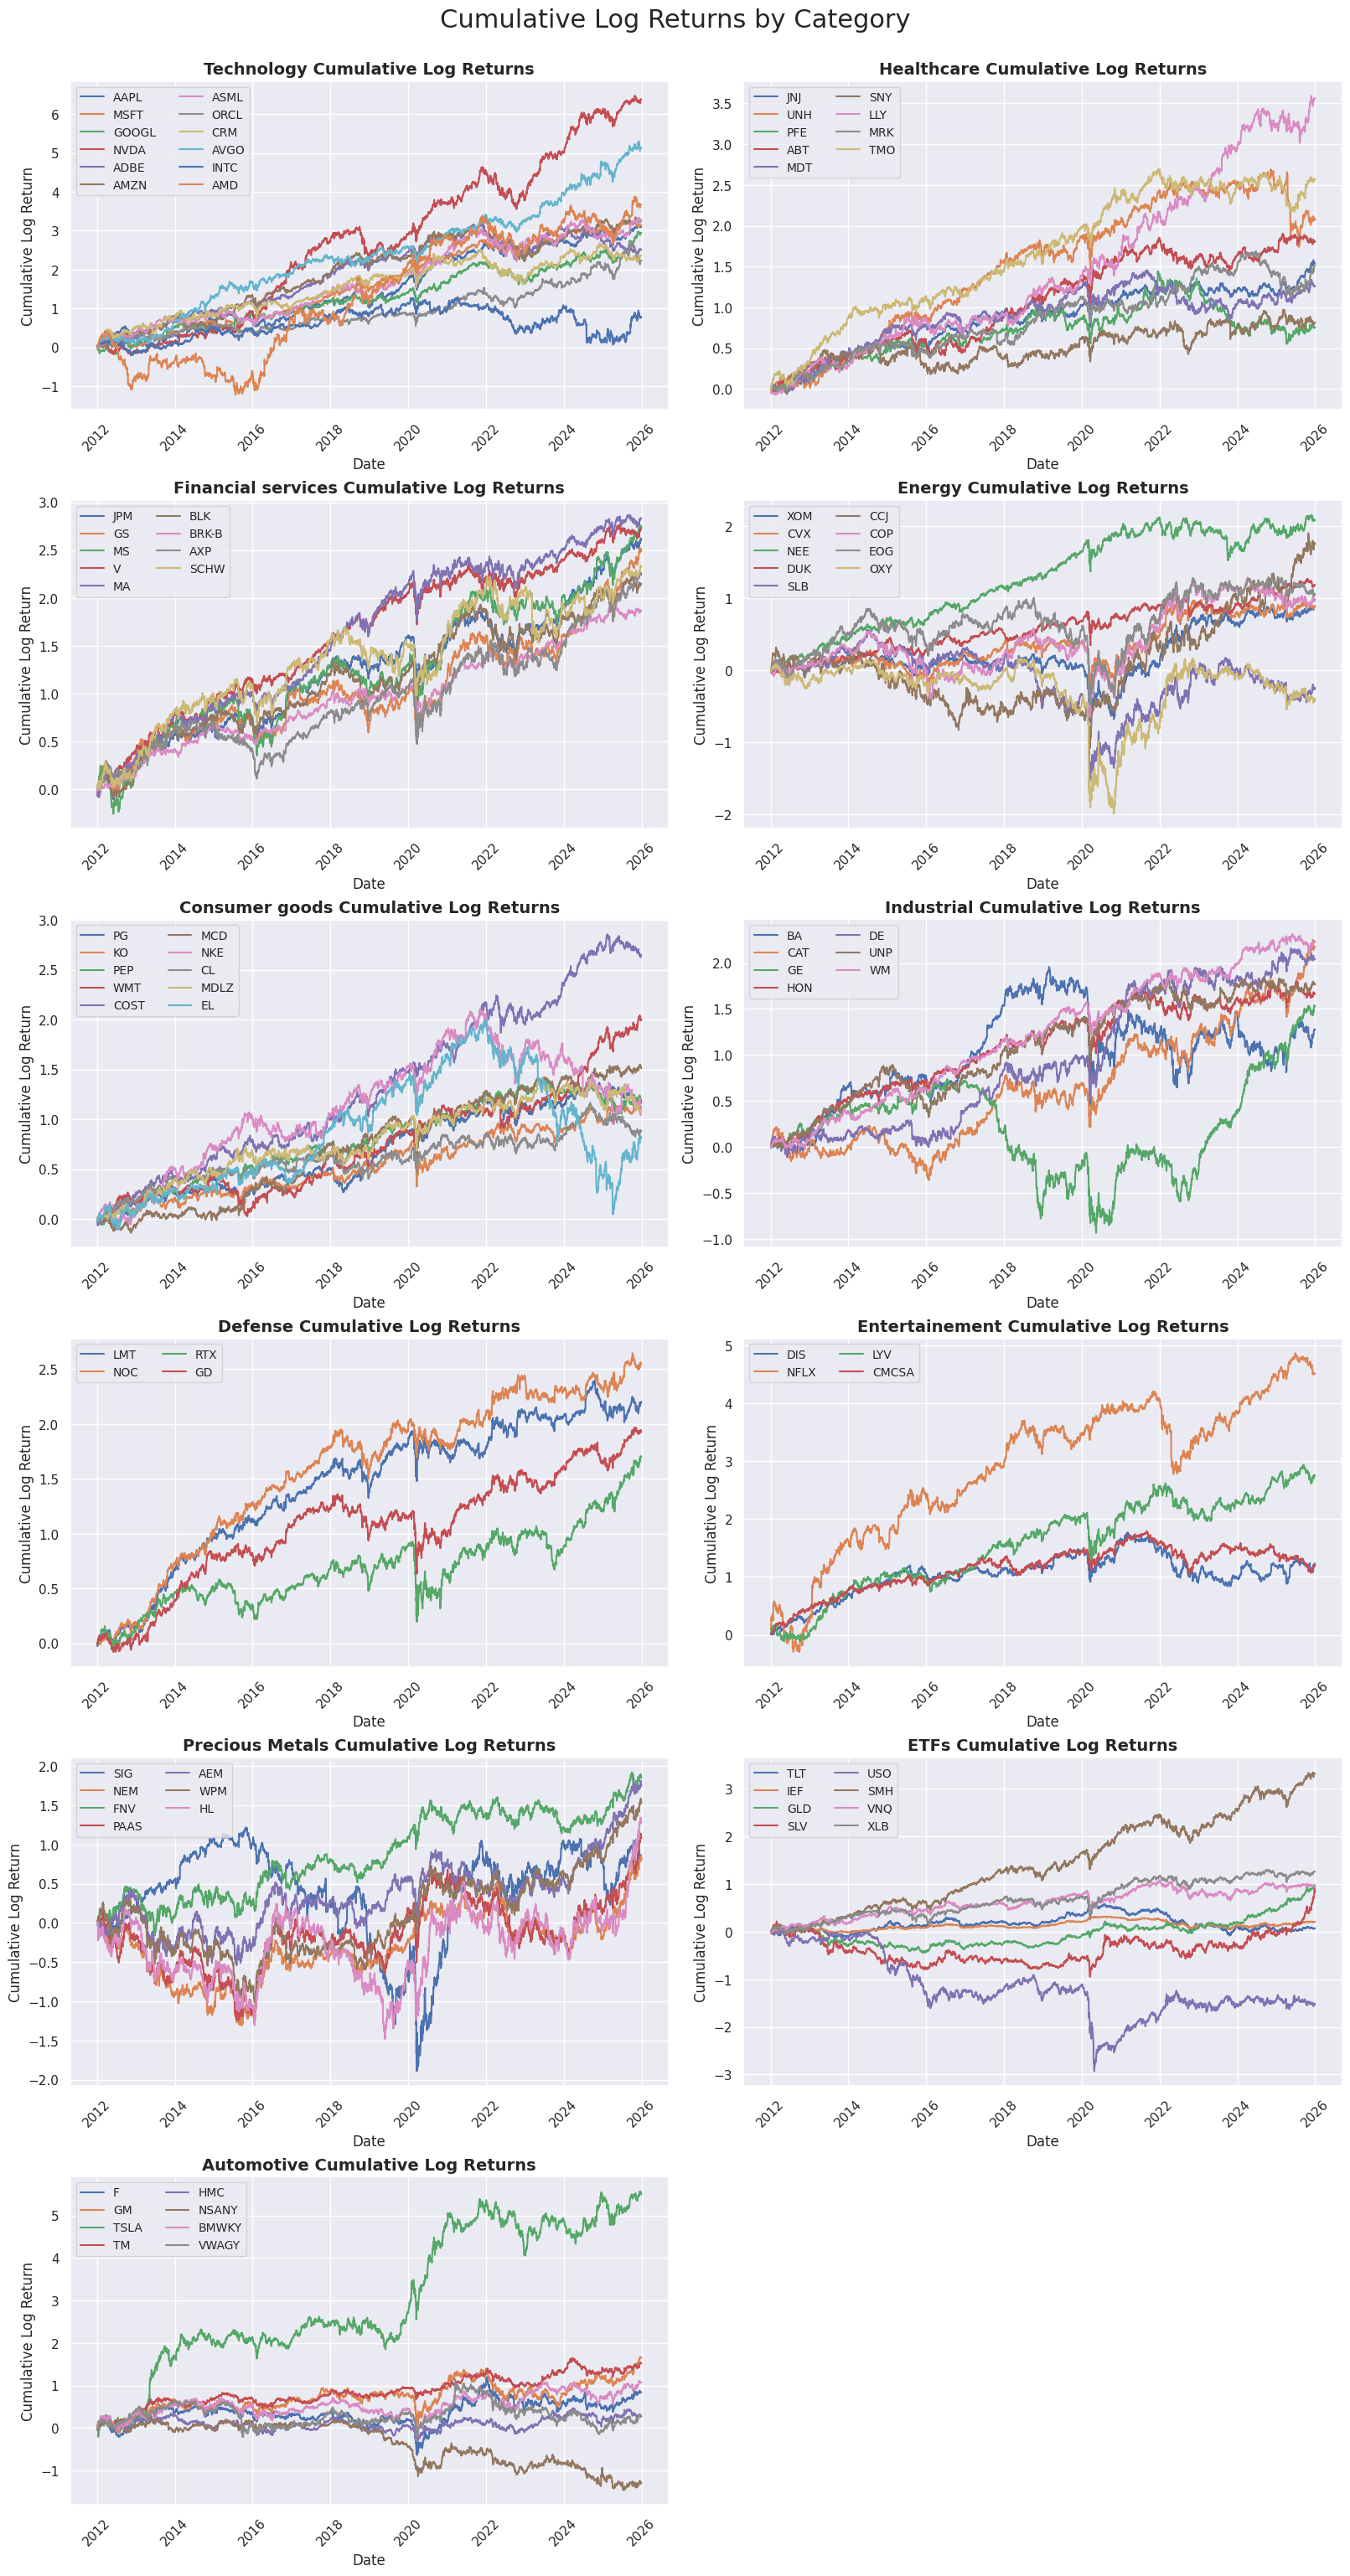

In [ ]:
sns.set_theme(style="darkgrid")

n_groups = len(groups)
cols = 2
rows = (n_groups + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (group_name, symbols) in enumerate(groups.items()):
    valid_symbols = [s for s in symbols if s in log_returns.columns]

    if not valid_symbols:
        axes[i].set_title(f"{group_name} (No Data)")
        continue

    for symbol in valid_symbols:
        axes[i].plot(log_returns.index, log_returns[symbol].cumsum(), label=symbol, linewidth=1.5)  # ".cumsum" -> cumulative

    axes[i].set_title(f"{group_name} Cumulative Log Returns", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Cumulative Log Return")
    axes[i].legend(loc='upper left', fontsize='small', ncol=2)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Cumulative Log Returns by Category", fontsize=22, y=1.02)
plt.show()

Finally, we can perform the **train-test split** under the following criteria:

* The *train set* will contain market days from 2012-01-03 to 2019-12-31.
* The *test set* will contain market days from 2022-01-01 to 2025-12-31.
* Years 2020 and 2021 have been removed from the analysis, since the market was too heavily influenced by Covid-19 to result helpful.

In [ ]:
train_returns = log_returns.loc[:"2019-12-31"]
test_returns = log_returns.loc["2022-01-01":]

print(f"Train: {train_returns.shape}")
print(f"Test: {test_returns.shape}")

Train: (2011, 88)
Test: (1002, 88)


This returns 2011 days of observations for the train set, and 1002 days for the test set.

### 2.1. **Functions**

Now, the following functions are created. This way, it's possible to compute indexes and ratios that will be used to assess which assets should be included in our portfolio.

The chosen metrics are:

* **Drawdowns**, the percentage decline from the previous peak of a portfolio or asset value. It's a risk measure that considers the sequence of returns.
* **Beta**, the difference in volatity with respect to the market benchmark. A beta smaller than 1 means that the asset is less volatile than the benchmark, and vice versa.
* **VaR (Historical)**, the Value at Risk. This measure estimates the worst loss expected over a period with a given confidence level (in this case, 95%), it's a simple and effective index but works on the assumption that history will only repeat itself.
* **Conditional VaR (Historical)**, an improved version of VaR that measures the average loss conditional on being in the worst tail; while VaR only detects where the tail starts, Conditional VaR also considers how bad the tail is once one's inside it.
* **Semi-standard deviation**, which measures volatility but using only negative returns; this is because investors dislike negative volatility, but are not particularly affected by positive volatility.

First, we have to set up parameters:

In [ ]:
TRADING_DAYS = 252
VAR_CONFIDENCE = 0.95
RISK_FREE_RATE = 0.02

Now, the functions are defined as follows:

In [ ]:
def compute_drawdowns(cumulative_returns):

    rolling_max = cumulative_returns.cummax()

    drawdowns = (cumulative_returns - rolling_max) / rolling_max

    return drawdowns


def compute_beta(asset_returns, market_returns):

    aligned = pd.concat(
        [asset_returns, market_returns],
        axis=1
    ).dropna()

    if len(aligned) < 30:
        return np.nan

    y = aligned.iloc[:, 0]
    x = aligned.iloc[:, 1]

    x = add_constant(x)

    model = OLS(y, x).fit()

    return model.params.iloc[1]


def historical_var(returns, confidence=0.95):

    if len(returns) == 0:
        return np.nan

    percentile = (1 - confidence) * 100

    return np.percentile(returns, percentile)


def historical_cvar(returns, confidence=0.95):

    var = historical_var(returns, confidence)

    tail_losses = returns[returns <= var]

    if len(tail_losses) == 0:
        return np.nan

    return tail_losses.mean()


def semi_std_dev(returns):

    negative_returns = returns[returns < 0]

    if len(negative_returns) == 0:
        return np.nan

    return negative_returns.std() * np.sqrt(TRADING_DAYS)


We also define various **ratios** that will serve the same purpose:

* **Sharpe ratio**, which measures excess return earned per unit of total risk.
* **Treynor ratio**, evaluating excess return earned per unit of systematic risk (using *beta* instead of *VaR*).
* **Sortino ratio**, this ratio only considers negative volatility, measuring excess return per unit of downside risk.
* **Calmar ratio**, computes the return earned per unit of worst historical loss.
* **Sterling ratio**, measures return per unit of average drawdown, being more stable than Calmar ratio.
* **Burke ratio**, this ratio confronts excess return relative to the cumulative severity of drawdowns, such that large drawdowns receive a disproportionate penalty.

These ratios are defined as follows:

In [ ]:
def sharpe_ratio(expected_return, std_dev, rf=RISK_FREE_RATE):
    """
    Sharpe Ratio
    SR = (Rp - Rf) / sigma
    """
    if std_dev == 0 or np.isnan(std_dev):
        return np.nan

    return (expected_return - rf) / std_dev


def treynor_ratio(expected_return, beta, rf=RISK_FREE_RATE):
    """
    Treynor Ratio
    TR = (Rp - Rf) / beta
    """
    if beta == 0 or np.isnan(beta):
        return np.nan

    return (expected_return - rf) / beta


def sortino_ratio(expected_return, downside_risk, rf=RISK_FREE_RATE):
    """
    Sortino Ratio
    SR = (Rp - Rf) / downside_risk
    """
    if downside_risk == 0 or np.isnan(downside_risk):
        return np.nan

    return (expected_return - rf) / downside_risk


def calmar_ratio(expected_return, max_drawdown):
    """
    Calmar Ratio
    CR = (Rp - Rf) / max_drawdown
    """
    if max_drawdown == 0 or np.isnan(max_drawdown):
        return np.nan

    return expected_return / abs(max_drawdown)


def sterling_ratio(expected_return, drawdowns):
    """
    Sterling Ratio
    SR = (Rp - Rf) / avg_dd
    """

    negative_dd = drawdowns[drawdowns < 0]

    if len(negative_dd) == 0:
        return np.nan

    avg_dd = abs(negative_dd.mean())

    if avg_dd == 0:
        return np.nan

    return expected_return / avg_dd


def burke_ratio(expected_return, drawdowns, rf=RISK_FREE_RATE):
    """
    Burke Ratio
    BR = (Rp - Rf) / sqrt(sum(dd^2))
    """

    negative_dd = drawdowns[drawdowns < 0]

    if len(negative_dd) == 0:
        return np.nan

    squared_drawdowns = np.square(negative_dd)

    denominator = np.sqrt(np.sum(squared_drawdowns))

    if denominator == 0:
        return np.nan

    return (expected_return - rf) / denominator

In [ ]:
market_returns = train_returns[BENCHMARK].dropna()
results = []

for company, ticker in tickers.items():

    print(f"Processing {company} ({ticker})")

    if ticker not in train_returns.columns:
        print(f"Ticker missing: {ticker}")
        continue

    asset_returns = train_returns[ticker].dropna()

    if len(asset_returns) < 50:
        print(f"Not enough data for {ticker}")
        continue

    try:

        cumulative = np.exp(asset_returns.cumsum())
        drawdowns = compute_drawdowns(cumulative)

        variance = asset_returns.var() * TRADING_DAYS
        std_dev = asset_returns.std() * np.sqrt(TRADING_DAYS)
        var95 = historical_var(asset_returns, VAR_CONFIDENCE)
        cvar95 = historical_cvar(asset_returns, VAR_CONFIDENCE)
        beta = compute_beta(asset_returns, market_returns)
        expected_return = asset_returns.mean() * TRADING_DAYS
        skewness_value = skew(asset_returns)
        kurtosis_value = kurtosis(asset_returns)
        max_drawdown = drawdowns.min()
        avg_drawdown = drawdowns[drawdowns < 0].mean()
        downside_risk = semi_std_dev(asset_returns)

        sharpe = sharpe_ratio(
            expected_return,
            std_dev
        )

        treynor = treynor_ratio(
            expected_return,
            beta
        )

        sortino = sortino_ratio(
            expected_return,
            downside_risk
        )

        calmar = calmar_ratio(
            expected_return,
            max_drawdown
        )

        sterling = sterling_ratio(
            expected_return,
            drawdowns
        )

        burke = burke_ratio(
            expected_return,
            drawdowns
        )

        results.append({
            "Company": company,
            "Ticker": ticker,
            "Variance_Annualized": variance,
            "Std_Dev_Annualized": std_dev,
            "VaR_95_Daily": var95,
            "CVaR_95_Daily": cvar95,
            "CAPM_Beta": beta,
            "Expected_Return_Annualized": expected_return,
            "Skewness": skewness_value,
            "Kurtosis": kurtosis_value,
            "Maximum_Drawdown": max_drawdown,
            "Average_Drawdown": avg_drawdown,
            "Semi_Std_Dev_Downside_Risk": downside_risk,
            "Sharpe_Ratio": sharpe,
            "Treynor_Ratio": treynor,
            "Sortino_Ratio": sortino,
            "Calmar_Ratio": calmar,
            "Sterling_Ratio": sterling,
            "Burke_Ratio": burke
        })

    except Exception as e:

        print(f"ERROR with {ticker}: {e}")

results_df_train = pd.DataFrame(results)

if len(results_df_train) == 0:
    raise ValueError("No valid results computed.")

results_df_train = results_df_train.sort_values(by="Company")

Processing APPLE (AAPL)
Processing MICROSOFT (MSFT)
Processing ALPHABET (GOOGL)
Processing NVIDIA (NVDA)
Processing ADOBE (ADBE)
Processing AMAZON (AMZN)
Processing ASML (ASML)
Processing ORACLE (ORCL)
Processing SALESFORCE (CRM)
Processing BROADCOM (AVGO)
Processing INTEL (INTC)
Processing AMD (AMD)
Processing META (META)
Ticker missing: META
Processing JOHNSON_JOHNSON (JNJ)
Processing UNITEDHEALTH (UNH)
Processing PFIZER (PFE)
Processing ABBOTT (ABT)
Processing MEDTRONIC (MDT)
Processing SANOFI (SNY)
Processing ELI_LILLY (LLY)
Processing MERCK (MRK)
Processing THERMO_FISHER (TMO)
Processing JPMORGAN_CHASE (JPM)
Processing GOLDMAN_SACHS (GS)
Processing MORGAN_STANLEY (MS)
Processing VISA (V)
Processing MASTERCARD (MA)
Processing BLACKROCK (BLK)
Processing BERKSHIRE_HATHAWAY (BRK-B)
Processing AMERICAN_EXPRESS (AXP)
Processing CHARLES_SCHWAB (SCHW)
Processing EXXON (XOM)
Processing CHEVRON (CVX)
Processing NEXTERA_ENERGY (NEE)
Processing DUKE_ENERGY (DUK)
Processing SCHLUMBERGER (SLB)


Let's explore the dataframe that contains these metrics:

In [ ]:
results_df_train.head()

,Company,Ticker,Variance_Annualized,Std_Dev_Annualized,VaR_95_Daily,CVaR_95_Daily,CAPM_Beta,Expected_Return_Annualized,Skewness,Kurtosis,Maximum_Drawdown,Average_Drawdown,Semi_Std_Dev_Downside_Risk,Sharpe_Ratio,Treynor_Ratio,Sortino_Ratio,Calmar_Ratio,Sterling_Ratio,Burke_Ratio
15,ABBOTT,ABT,0.037302,0.193136,-0.019062,-0.029159,0.998839,0.167223,-0.697241,5.488235,-0.281608,-0.066516,0.150068,0.762277,0.147394,0.981046,0.593816,2.514029,0.036652
4,ADOBE,ADBE,0.065596,0.256118,-0.023815,-0.036516,1.293331,0.306530,0.295455,6.474086,-0.255291,-0.045968,0.182416,1.118743,0.221544,1.570755,1.200711,6.668373,0.111636
68,AGNICO_EAGLE,AEM,0.178095,0.422013,-0.041762,-0.059242,0.206817,0.073023,0.134253,2.561575,-0.615450,-0.297084,0.282547,0.125642,0.256374,0.187659,0.118649,0.245798,0.003547
2,ALPHABET,GOOGL,0.052828,0.229843,-0.021955,-0.032814,1.132451,0.174397,0.575146,12.176322,-0.234018,-0.066896,0.164308,0.671748,0.136339,0.939677,0.745228,2.606985,0.043898
5,AMAZON,AMZN,0.087087,0.295104,-0.025723,-0.041956,1.302536,0.292503,0.383317,9.033733,-0.341038,-0.086097,0.212614,0.923412,0.209209,1.281680,0.857685,3.397350,0.056227


These results are in need of **normalisation**, ensuring that, during the clustering, no variable appears "more important" than others.

In [ ]:
numeric_cols = results_df_train.columns.drop(["Company", "Ticker"])
scaler = StandardScaler()

results_df_train_scaled = results_df_train.copy()

results_df_train_scaled[numeric_cols] = scaler.fit_transform(results_df_train[numeric_cols])
results_df_train_scaled.head()

,Company,Ticker,Variance_Annualized,Std_Dev_Annualized,VaR_95_Daily,CVaR_95_Daily,CAPM_Beta,Expected_Return_Annualized,Skewness,Kurtosis,Maximum_Drawdown,Average_Drawdown,Semi_Std_Dev_Downside_Risk,Sharpe_Ratio,Treynor_Ratio,Sortino_Ratio,Calmar_Ratio,Sterling_Ratio,Burke_Ratio
15,ABBOTT,ABT,-0.498169,-0.513377,0.487923,0.423168,0.185298,0.352477,-1.545535,0.030624,0.497130,0.587811,-0.333592,0.630716,0.201074,0.487889,0.291893,0.330668,0.217676
4,ADOBE,ADBE,-0.029998,0.151741,-0.048574,-0.119608,0.944890,1.626824,1.173661,0.251777,0.636175,0.763113,0.137375,1.464940,0.699468,1.475448,1.832193,2.706916,2.777576
68,AGNICO_EAGLE,AEM,1.831421,1.903672,-2.074055,-1.796125,-1.857587,-0.509247,0.732095,-0.625906,-1.266724,-1.379209,1.595217,-0.859176,0.933575,-0.840762,-0.914084,-0.966740,-0.912521
2,ALPHABET,GOOGL,-0.241267,-0.125733,0.161415,0.153496,0.529927,0.418098,1.939790,1.530944,0.748569,0.584570,-0.126257,0.418854,0.126763,0.418610,0.676176,0.383838,0.465059
5,AMAZON,AMZN,0.325581,0.563455,-0.263845,-0.520900,0.968635,1.498505,1.414333,0.825975,0.183131,0.420758,0.577040,1.007815,0.616559,0.991347,0.961591,0.835919,0.885970


Before proceeding with clustering, results are saved and downloaded.

In [ ]:
csv_file = "financial_metrics_2012_2019_RAW.csv"
csv_scaled_file = "financial_metrics_2012_2019_SCALED.csv"

results_df_train.to_csv(csv_file, index=False)
results_df_train_scaled.to_csv(csv_scaled_file, index=False)

pd.set_option("display.max_columns", None)

print("\nSaved files:")
print(csv_file)
print(csv_scaled_file)


Saved files:
financial_metrics_2012_2019_RAW.csv
financial_metrics_2012_2019_SCALED.csv


## 3. **Clustering**

Before starting, clustering requires only numerical values, so we set *Ticker* as index and transpose the data matrix.

In [ ]:
data = train_returns.copy()

if BENCHMARK in data.columns:
    data = data.drop(columns=BENCHMARK)

X = data.T

X.head()

Date    2012-01-04  2012-01-05  2012-01-06  2012-01-09  2012-01-10  \
Ticker                                                               
AAPL      0.005360    0.011041    0.010399   -0.001587    0.003574   
ABT      -0.003886   -0.002303   -0.009089   -0.000179    0.004645   
ADBE     -0.010202    0.007047    0.008392   -0.006638    0.023213   
AEM      -0.020325    0.012192   -0.005283    0.007388    0.005767   
AMD      -0.003656    0.000000   -0.005510    0.029040    0.021240   

Date    2012-01-11  2012-01-12  2012-01-13  2012-01-17  2012-01-18  \
Ticker                                                               
AAPL     -0.001632   -0.002749   -0.003757    0.011581    0.010331   
ABT      -0.003782   -0.004703    0.004883    0.005039   -0.006303   
ADBE      0.004101   -0.003074   -0.008935    0.013032    0.018231   
AEM      -0.013684   -0.007714   -0.011818   -0.040530    0.011470   
AMD       0.017362    0.001720   -0.027876    0.012292    0.041031   

Date    2012-01-19  2012-01-20  2012-01-23  2012-01-24  2012-01-25  \
Ticker                                                               
AAPL     -0.003175   -0.017570    0.016775   -0.016513    0.060568   
ABT       0.001264    0.005936   -0.000717    0.004655   -0.013488   
ADBE      0.011642    0.008561   -0.008892    0.023538    0.012522   
AEM       0.001112   -0.023901    0.009911   -0.029162    0.086383   
AMD       0.041023    0.031648    0.015456    0.001533    0.030168   

Date    2012-01-26  2012-01-27  2012-01-30  2012-01-31  2012-02-01  \
Ticker                                                               
AAPL     -0.004556    0.005942    0.012730    0.007630   -0.000635   
ABT      -0.006539    0.002730   -0.010047   -0.005892    0.002029   
ADBE     -0.005118   -0.004178   -0.001612   -0.001614    0.009326   
AEM       0.005572    0.038926   -0.042372   -0.006928   -0.000802   
AMD       0.005926    0.007358   -0.011800   -0.004461    0.027922   

Date    2012-02-02  2012-02-03  2012-02-06  2012-02-07  2012-02-08  \
Ticker                                                               
AAPL     -0.002348    0.009969    0.009289    0.010421    0.016605   
ABT       0.003496    0.010050    0.007066    0.005761   -0.002516   
ADBE      0.001599    0.017739    0.000314    0.013096   -0.005592   
AEM       0.003206   -0.028957    0.004931   -0.012648   -0.017868   
AMD       0.004338    0.021414   -0.022858    0.029895    0.016690   

Date    2012-02-09  2012-02-10  2012-02-13  2012-02-14  2012-02-15  \
Ticker                                                               
AAPL      0.034008    0.000507    0.018434    0.013556   -0.023414   
ABT      -0.005594   -0.002718    0.000907   -0.001451    0.006875   
ADBE      0.016989   -0.013568    0.004337    0.002778    0.000616   
AEM       0.003656   -0.026160   -0.005489   -0.017829    0.008808   
AMD      -0.001380   -0.026594    0.033476    0.004107   -0.002736   

Date    2012-02-16  2012-02-17  2012-02-21  2012-02-22  2012-02-23  \
Ticker                                                               
AAPL      0.009081   -0.000179    0.025036   -0.003522    0.006508   
ABT       0.007008    0.009090   -0.003555    0.001246    0.001066   
ADBE      0.012248   -0.003353   -0.006433   -0.006474    0.019602   
AEM       0.067257   -0.031934    0.030292    0.027007    0.000267   
AMD       0.038957   -0.022653   -0.019048   -0.019418    0.020791   

Date    2012-02-24  2012-02-27  2012-02-28  2012-02-29  2012-03-01  \
Ticker                                                               
AAPL      0.011591    0.006392    0.018188    0.013045    0.003735   
ABT       0.007258   -0.001766    0.007744   -0.007567    0.012464   
ADBE      0.013257   -0.004199    0.000000   -0.011487    0.006365   
AEM      -0.017196   -0.013368    0.028316   -0.025834    0.012048   
AMD       0.023052    0.001340    0.006671   -0.022866    0.021535   

Date    2012-03-02  2012-03-05  2012-03-06  2012-03-07  2012-03-08  \
Ti

Now, it's time to perform **clustering**.

The first required item is the **distance matrix**, which will be used to group assets into clusters.

Our goal is to pick assets as different as possible, i. e. we want assets that don't vary together. If possible, we would like that, when an asset is decreasing, another one would rise.

So, we create a distance matrix based on **correlation**, such that perfect positive correlation is equal to 0, independence is 0.5, and perfect negative correlation is equal to 1.

In [ ]:
corr = X.T.corr()

distance = np.sqrt(0.5 * (1 - corr))

distance

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,BLK,BMWKY,BRK-B,CAT,CCJ,CL,CMCSA,COP,COST,CRM,CVX,DE,DIS,DUK,EL,EOG,F,FNV,GD,GE,GLD,GM,GOOGL,GS,HL,HMC,HON,IEF,INTC,JNJ,JPM,KO,LLY,LMT,LYV,MA,MCD,MDLZ,MDT,MRK,MS,MSFT,NEE,NEM,NFLX,NKE,NOC,NSANY,NVDA,ORCL,OXY,PAAS,PEP,PFE,PG,RTX,SCHW,SIG,SLB,SLV,SMH,SNY,TLT,TM,TMO,TSLA,UNH,UNP,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000000,0.577291,0.558191,0.683872,0.609643,0.566135,0.555440,0.522214,0.582011,0.575716,0.559515,0.585050,0.552595,0.560230,0.628981,0.623584,0.596808,0.607599,0.600145,0.573021,0.595801,0.577027,0.585866,0.681020,0.602800,0.608872,0.596650,0.689473,0.585380,0.609929,0.713662,0.591709,0.537961,0.561430,0.666051,0.591632,0.550614,0.780637,0.549703,0.615120,0.574521,0.630363,0.627927,0.592941,0.606058,0.528384,0.612374,0.617579,0.588448,0.624771,0.574698,0.534668,0.664898,0.682246,0.629008,0.595399,0.596924,0.613376,0.564641,0.568845,0.604989,0.680569,0.623655,0.611152,0.624887,0.561225,0.587726,0.642493,0.593826,0.679436,0.484218,0.612061,0.780174,0.588051,0.563602,0.618155,0.595599,0.573712,0.637268,0.550405,0.610782,0.607469,0.608657,0.632966,0.670560,0.532039,0.593452
ABT,0.577291,0.000000,0.528481,0.705002,0.606742,0.572247,0.549535,0.575054,0.521791,0.540915,0.489281,0.570662,0.485294,0.567837,0.622834,0.559235,0.570399,0.593536,0.551942,0.560453,0.558011,0.575076,0.549423,0.624982,0.566494,0.599751,0.577351,0.699030,0.533436,0.591278,0.725216,0.578527,0.538512,0.534055,0.683034,0.556283,0.497926,0.773942,0.543743,0.505441,0.531179,0.569537,0.517980,0.550049,0.576121,0.497313,0.570103,0.563457,0.463858,0.503206,0.533216,0.529551,0.613296,0.686629,0.625225,0.569213,0.558741,0.588937,0.582739,0.544607,0.583020,0.690973,0.562161,0.500217,0.575123,0.529247,0.531030,0.635641,0.597800,0.693974,0.506752,0.546865,0.774163,0.556474,0.450454,0.629913,0.544985,0.560724,0.652570,0.499400,0.548981,0.597200,0.563213,0.583654,0.689612,0.488937,0.554107
ADBE,0.558191,0.528481,0.000000,0.688780,0.590175,0.512291,0.522304,0.557642,0.544683,0.553039,0.518981,0.562175,0.528565,0.557172,0.628599,0.596709,0.578438,0.591834,0.575650,0.455321,0.584403,0.580631,0.563006,0.648675,0.563176,0.586951,0.594946,0.689464,0.540780,0.592861,0.716874,0.584585,0.499537,0.542282,0.672403,0.561876,0.509610,0.773221,0.543141,0.566287,0.556283,0.593680,0.595189,0.560126,0.558391,0.456935,0.588682,0.580471,0.546322,0.586923,0.539460,0.471279,0.624048,0.684140,0.576810,0.550706,0.561935,0.588294,0.526014,0.527253,0.589685,0.682084,0.595179,0.576257,0.616285,0.526207,0.554531,0.636604,0.603481,0.685883,0.465835,0.574135,0.774675,0.556761,0.495714,0.592516,0.577048,0.562141,0.637695,0.459080,0.563349,0.593576,0.573975,0.619419,0.673223,0.503386,0.583254
AEM,0.683872,0.705002,0.688780,0.000000,0.691724,0.694482,0.689602,0.693046,0.708432,0.707234,0.703555,0.687550,0.714018,0.669388,0.654892,0.682749,0.690934,0.661263,0.714768,0.697572,0.651488,0.680326,0.712873,0.651353,0.689170,0.656033,0.695856,0.330135,0.699291,0.700334,0.380938,0.692216,0.705909,0.716159,0.408582,0.696853,0.689498,0.615085,0.692175,0.703023,0.727126,0.685947,0.694817,0.706451,0.695212,0.704241,0.706390,0.688905,0.687842,0.700691,0.719531,0.694885,0.653724,0.341883,0.701376,0.723305,0.697626,0.681230,0.706430,0.683756,0.646567,0.352326,0.696003,0.707886,0.692293,0.693829,0.748084,0.721283,0.655951,0.425884,0.688734,0.676735,0.638415,0.697197,0.687744,0.694189,0.708852,0.701168,0.656934,0.708564,0.655130,0.686928,0.694702,0.710458,0.324509,0.637850,0.659007
AMD,0.609643,0.606742,0.590175,0.691724,0.000000,0.612379,0.591580,0.592065,0.601725,0.614901,0.599896,0.604250,0.600466,0.600474,0.645367,0.643193,0.637702,0.611823,0.647575,0.602115,0.614868,0.614290,0.620427,0.686336,0.619912,0.618745,0.616851,0.690522,0.618446,0.628623,0.713280,0.614251,0.628838,0.600992,0.673689,0.616756,0.590387,0.766426,0.582907,0.649975,0.604195,0.652972,0.659873,0.

To ease the next steps, we pass to the condensed form of the matrix.

In [ ]:
dist_condensed = squareform(distance.values)
dist_condensed

array([0.57729135, 0.55819107, 0.68387204, ..., 0.60317393, 0.64413963,
       0.43236664])

And standardise the results. We need to go back to the untransposed matrix to scaled on the time axis, then transpose again.

In [ ]:
scaler_ts = StandardScaler()

X_scaled = scaler_ts.fit_transform(X.T).T

We also perform PCA with two components on each asset. This is uninfluent for the clustering itself, but will be useful in picturing assets as points on a 2D plot.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

This **loop** will be used to identify the best value of *k*, i.e. the best number of cluster, for each method. Clusters will be evaluated through **silhouette scores**, which measures how similar a data point is to its own cluster compared to other clusters.

We have chosen three **clustering methods** to compare:

* **K-Means** is a machine learning algorithm  that measures the distance between data points and assigning them to the nearest centroid, so that points in the same group are as similar as possible.
* **Hierarchical Clustering: Ward** is a hierarchical algorithm that starts with all assets as singlets and then merges the two most similar clusters until it reaches unity. Specifically, Ward's method performs merges with the goal of minimising the total within-clusters variance.
* **Hierarchical Clustering: Complete Linkage** is another example of hierarchical clustering algorithm, where clusters are merged by considering the closest pair. Here, distance is evaluated through the complete linkage method.

For each method, the selected number of clusters will be displayed after the loop.

In [ ]:
k_values = range(3, 60)

silhouette_scores = {
    "KMeans": [],
    "Ward": [],
    "Complete": []
}

Z_ward = linkage(dist_condensed, method="ward")
Z_comp = linkage(dist_condensed, method="complete")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = kmeans.fit_predict(X_scaled)
    sil_k = silhouette_score(X_scaled, k_labels, metric='euclidean')
    silhouette_scores["KMeans"].append(sil_k)

    w_labels = fcluster(Z_ward, k, criterion="maxclust")
    sil_w = silhouette_score(distance.values, w_labels, metric='precomputed')
    silhouette_scores["Ward"].append(sil_w)

    c_labels = fcluster(Z_comp, k, criterion="maxclust")
    sil_c = silhouette_score(distance.values, c_labels, metric='precomputed')
    silhouette_scores["Complete"].append(sil_c)


best_k_kmeans = k_values[np.argmax(silhouette_scores["KMeans"])]
best_k_ward = k_values[np.argmax(silhouette_scores["Ward"])]
best_k_comp = k_values[np.argmax(silhouette_scores["Complete"])]

print(f"Best k for K-Means: {best_k_kmeans} (Score: {max(silhouette_scores['KMeans']):.4f})")
print(f"Best k for Hierarchical Ward: {best_k_ward} (Score: {max(silhouette_scores['Ward']):.4f})")
print(f"Best k for Hierarchical Complete: {best_k_comp} (Score: {max(silhouette_scores['Complete']):.4f})")

FINAL_K = best_k_ward
final_kmeans_labels = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10).fit_predict(X_scaled)
final_ward_labels = fcluster(Z_ward, best_k_ward, criterion="maxclust")
final_comp_labels = fcluster(Z_comp, best_k_comp, criterion="maxclust")

Best k for K-Means: 28 (Score: 0.1313)
Best k for Hierarchical Ward: 34 (Score: 0.1443)
Best k for Hierarchical Complete: 36 (Score: 0.1380)


Now, let's plot the clusters produced by each method and compare the silhouettes.

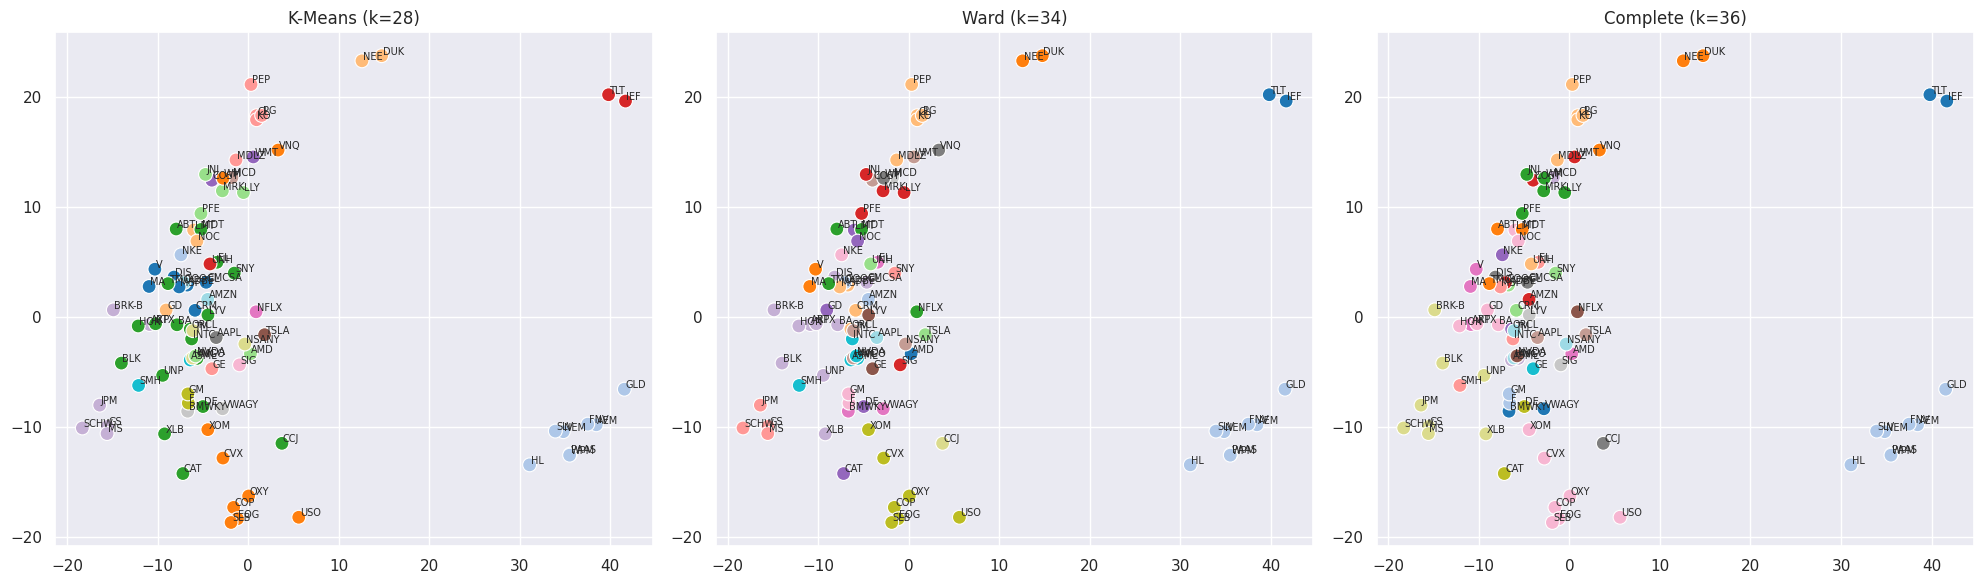

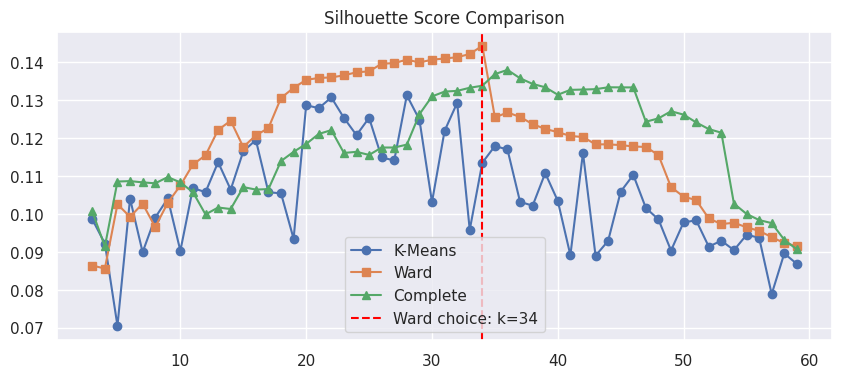

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = [
    ("K-Means (k={})".format(best_k_kmeans), final_kmeans_labels),
    ("Ward (k={})".format(best_k_ward), final_ward_labels),
    ("Complete (k={})".format(best_k_comp), final_comp_labels)
]

for i, (title, labels) in enumerate(methods):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="tab20", s=100, ax=axes[i], legend=None)
    for j, txt in enumerate(X.index):
        axes[i].text(X_pca[j, 0]+0.1, X_pca[j, 1]+0.1, txt, fontsize=7)
    axes[i].set_title(title)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(k_values, silhouette_scores["KMeans"], marker='o', label="K-Means")
plt.plot(k_values, silhouette_scores["Ward"], marker='s', label="Ward")
plt.plot(k_values, silhouette_scores["Complete"], marker='^', label="Complete")
plt.axvline(x=FINAL_K, color='red', linestyle='--', label=f'Ward choice: k={FINAL_K}')
plt.title("Silhouette Score Comparison")
plt.legend()
plt.show()

The best choice appears to be the Hierarchical Ward technique, and the best value of *k* is 34.

Now, we use the **dendogram** to trace the clustering process of the Ward algorithm and visualise the 34 clusters.

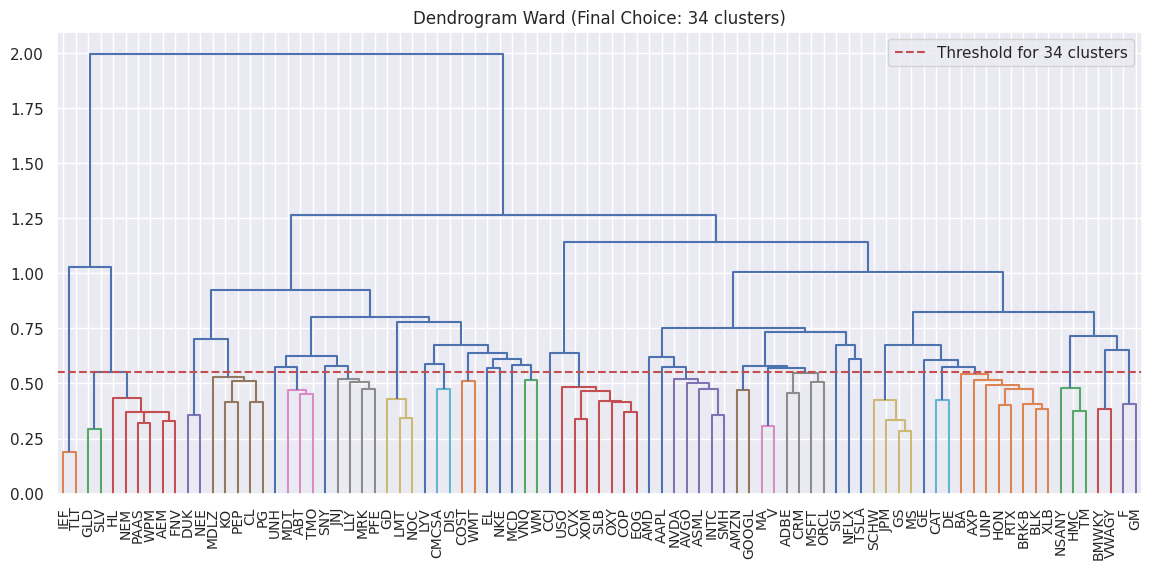

In [ ]:
plt.figure(figsize=(14, 6))
threshold = Z_ward[-(FINAL_K), 2] if len(Z_ward) >= FINAL_K else 0

dendrogram(Z_ward, labels=X.index, leaf_rotation=90, leaf_font_size=10, color_threshold=threshold)

plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold for {FINAL_K} clusters')

plt.title(f"Dendrogram Ward (Final Choice: {FINAL_K} clusters)")
plt.legend()
plt.show()

Finally, we visualise the labels and add them to the dataframe:

In [ ]:
print(final_ward_labels)

cluster_mapping = dict(zip(X.index, final_ward_labels))

results_df_train_scaled['Cluster_Ward'] = results_df_train_scaled['Ticker'].map(cluster_mapping)

results_df_train_scaled

[20  5 24  2 21 22 19 19 30 30 30 33 30 29 18  4 10 17 12 24 17 29 10  3
 13 17 34  2  9 31  2 34 22 28  2 32 30  1 19  7 28  4  7  9 11 23 16  4
  5  7 28 24  3  2 25 14  9 32 19 24 17  2  4  7  4 30 28 27 17  2 19  8
  1 32  5 26  6 30 17 23 15 33 15 12  2 30 17]


,Company,Ticker,Variance_Annualized,Std_Dev_Annualized,VaR_95_Daily,CVaR_95_Daily,CAPM_Beta,Expected_Return_Annualized,Skewness,Kurtosis,Maximum_Drawdown,Average_Drawdown,Semi_Std_Dev_Downside_Risk,Sharpe_Ratio,Treynor_Ratio,Sortino_Ratio,Calmar_Ratio,Sterling_Ratio,Burke_Ratio,Cluster_Ward
15,ABBOTT,ABT,-0.498169,-0.513377,0.487923,0.423168,0.185298,0.352477,-1.545535,0.030624,0.497130,0.587811,-0.333592,0.630716,0.201074,0.487889,0.291893,0.330668,0.217676,5
4,ADOBE,ADBE,-0.029998,0.151741,-0.048574,-0.119608,0.944890,1.626824,1.173661,0.251777,0.636175,0.763113,0.137375,1.464940,0.699468,1.475448,1.832193,2.706916,2.777576,24
68,AGNICO_EAGLE,AEM,1.831421,1.903672,-2.074055,-1.796125,-1.857587,-0.509247,0.732095,-0.625906,-1.266724,-1.379209,1.595217,-0.859176,0.933575,-0.840762,-0.914084,-0.966740,-0.912521,2
2,ALPHABET,GOOGL,-0.241267,-0.125733,0.161415,0.153496,0.529927,0.418098,1.939790,1.530944,0.748569,0.584570,-0.126257,0.418854,0.126763,0.418610,0.676176,0.383838,0.465059,22
5,AMAZON,AMZN,0.325581,0.563455,-0.263845,-0.520900,0.968635,1.498505,1.414333,0.825975,0.183131,0.420758,0.577040,1.007815,0.616559,0.991347,0.961591,0.835919,0.885970,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,VISA,V,-0.409343,-0.371541,0.320118,0.398483,0.504020,1.167392,0.455897,-0.239795,0.974432,0.835447,-0.394857,1.523981,0.625474,1.558080,2.185792,2.803290,2.876616,23
86,VOLKSWAGEN,VWAGY,0.304866,0.540972,-0.463205,-0.490702,0.488160,-0.793875,-1.861249,0.968420,-1.075027,-1.137929,0.614018,-0.978212,-0.657709,-0.984505,-1.031568,-1.018157,-0.979613,33
42,WALMART,WMT,-0.597033,-0.683857,0.880079,0.673903,-0.899165,-0.172610,-0.003275,2.685999,0.059952,0.271047,-0.530524,0.034453,0.254186,-0.053369,-0.450213,-0.501258,-0.507760,12
55,WASTE_MANAGEMENT,WM,-0.767851,-1.022527,1.159239,1.021476,-0.778423,0.512187,-0.154385,0.203735,1.177519,0.833321,-0.933820,1.506119,0.980827,1.378812,1.851727,1.691862,1.699292,15


So, the clusters we found are the following:

In [ ]:
clusters = results_df_train_scaled.groupby('Cluster_Ward')['Company'].apply(list)

for cluster_id, stocks in clusters.items():
    print(f"Cluster {cluster_id}: {', '.join(stocks)}")

Cluster 1: LONG_TREASURIES_ETF, MEDIUM_TREASURIES_ETF
Cluster 2: AGNICO_EAGLE, FRANCO_NEVADA, GOLD_ETF, HECLA_MINING, NEWMONT_GOLD, PAN_AMERICAN_SILVER, SILVER_ETF, WHEATON_PRECIOUS_METALS
Cluster 3: DUKE_ENERGY, NEXTERA_ENERGY
Cluster 4: COCA_COLA, COLGATE_PALMOLIVE, MONDELEZ, PEPSICO, PROCTER_GAMBLE
Cluster 5: ABBOTT, MEDTRONIC, THERMO_FISHER
Cluster 6: UNITEDHEALTH
Cluster 7: ELI_LILLY, JOHNSON_JOHNSON, MERCK, PFIZER
Cluster 8: SANOFI
Cluster 9: GENERAL_DYNAMICS, LOCKHEED_MARTIN, NORTHROP_GRUMMAN
Cluster 10: COMCAST, DISNEY
Cluster 11: LIVE_NATION
Cluster 12: COSTCO, WALMART
Cluster 13: ESTEE_LAUDER
Cluster 14: NIKE
Cluster 15: REAL_ESTATE_ETF, WASTE_MANAGEMENT
Cluster 16: MCDONALDS
Cluster 17: CHEVRON, CONOCOPHILLIPS, EOG_RESOURCES, EXXON, OCCIDENTAL_PETROLEUM, OIL_ETF, SCHLUMBERGER
Cluster 18: CAMECO
Cluster 19: ASML, BROADCOM, INTEL, NVIDIA, SEMICONDUCTORS_ETF
Cluster 20: APPLE
Cluster 21: AMD
Cluster 22: ALPHABET, AMAZON
Cluster 23: MASTERCARD, VISA
Cluster 24: ADOBE, MICROSOFT,

We can observe that the algorithm successfully identified market structures using only price correlations. The model grouped assets into their specific economic sectors, such as fixed income (Cluster 1), precious metals (Cluster 2), consumer staples (Cluster 4), oil and gas (Cluster 17), and semiconductors (Cluster 19).

The model also captured distinct behavioral differences within the same macro-sectors:


*   Healthcare & Pharma: Healthcare was split into medical devices/services (Cluster 5), giant insurers like UnitedHealth (Cluster 6), big pharma (Cluster 7), and Sanofi on its own (Cluster 8).
*   Technology & Communication: Instead of a single tech block, the model isolated hardware/semiconductors (Cluster 19) from software/cloud infrastructure (Cluster 24), while keeping mega-caps like Apple (Cluster 20), AMD (Cluster 21), and Alphabet/Amazon (Cluster 22) in independent or highly concentrated groups.
*   Financials & Payments: Visa and Mastercard (Cluster 23) were grouped together completely separated from traditional investment banks (Cluster 28), reflecting their unique behavior as tech-driven payment rails rather than classic financial institutions.
*   Automotive: The algorithm even separated car manufacturers by geography/investment profile, separating Japanese automakers (Cluster 32), German luxury brands (Cluster 33), and American legacy automotive companies (Cluster 34), while leaving Tesla (Cluster 26) isolated due to its high-growth stock behavior.

Finally, we notice the presence of several single-asset clusters reflecting unique market behaviors, including UnitedHealth (Cluster 6), Sanofi (Cluster 8), Live Nation (Cluster 11), Estée Lauder (Cluster 13), Nike (Cluster 14), McDonald's (Cluster 16), Cameco (Cluster 18), Apple (Cluster 20), AMD (Cluster 21), Netflix (Cluster 25), Tesla (Cluster 26), Signet (Cluster 27), and General Electric (Cluster 31).

---

The portfolio we want to build must pick the best asset in every group.

## 4. **Portfolio creation**

Now, we want to find out which asset in each cluster is the best.

To do so, we will look at the **Calmar Ratio** and **Sortino Ratio**. Both need to be normalised before using them.

* The **Calmar Ratio** is a financial metric used to evaluate an investment’s risk-adjusted returns. It measures how much return a portfolio generates relative to its "drawdown" (the maximum peak-to-trough drop in value); its formula is *expected return* over *maximum drawdown*.
* The **Sortino Ratio** is a s a financial metric used to measure the risk-adjusted performance of an investment. It refines the popular Sharpe ratio by isolating downside volatility (negative returns or losses) rather than penalizing all volatility, meaning it does not punish an investment for generating positive gains. Its formula is *(expected_return - rf) / downside_risk*.

In this project, we chose to pick the asset with the highest Sortino Ratio. It's equally possible doing the same using the Calmar Ratio.

In [ ]:
def best_company_in_cluster(data, target_cluster):

    cluster_df = data[
        data["Cluster_Ward"] == target_cluster
    ].copy()

    if cluster_df.empty:
        print(f"No assets in cluster {target_cluster}")
        return None

    cluster_df["Calmar_norm"] = (
        (cluster_df["Calmar_Ratio"] - cluster_df["Calmar_Ratio"].min()) /
        (cluster_df["Calmar_Ratio"].max() - cluster_df["Calmar_Ratio"].min() + 1e-9)
    )

    cluster_df["Sortino_norm"] = (
        (cluster_df["Sortino_Ratio"] - cluster_df["Sortino_Ratio"].min()) /
        (cluster_df["Sortino_Ratio"].max() - cluster_df["Sortino_Ratio"].min() + 1e-9)
    )

    best_row = cluster_df.sort_values(
        by="Sortino_norm",
        ascending=False
    ).iloc[0]


    print(f"Best stock in cluster {target_cluster} by Sortino Ratio")

    print(f"Company : {best_row['Company']}")
    print(f"Ticker  : {best_row['Ticker']}")

    print("\nCalmar and Sortino Ratio:")
    print(f"Calmar Ratio  : {best_row['Calmar_Ratio']:.4f}")
    print(f"Sortino Ratio : {best_row['Sortino_Ratio']:.4f}")

    print("\nAll stock metrics:\n")

    cols_to_exclude = [
        "Calmar_norm",
        "Sortino_norm",
    ]

    for col in cluster_df.columns:
        if col not in cols_to_exclude:
            print(f"{col:35}: {best_row[col]}")

    return best_row

Let's see the results:

In [ ]:
best_companies = []

for cluster in sorted(results_df_train_scaled["Cluster_Ward"].unique()):

    print("\n")

    best = best_company_in_cluster(
        data=results_df_train_scaled,
        target_cluster=cluster
    )

    if best is not None:
        best_companies.append(best)

best_companies_df = pd.DataFrame(best_companies)

print("\n")
print("Best stock by cluster:")



Best stock in cluster 1 by Sortino Ratio
Company : LONG_TREASURIES_ETF
Ticker  : TLT

Calmar and Sortino Ratio:
Calmar Ratio  : -0.7011
Sortino Ratio : -0.7165

All stock metrics:

Company                            : LONG_TREASURIES_ETF
Ticker                             : TLT
Variance_Annualized                : -0.8627901113215991
Std_Dev_Annualized                 : -1.2482251773220512
VaR_95_Daily                       : 1.1335179302679161
CVaR_95_Daily                      : 1.303483733297196
CAPM_Beta                          : -3.345827896153406
Expected_Return_Annualized         : -0.7944548631941746
Skewness                           : -0.42957941923007925
Kurtosis                           : -1.0026113802310945
Maximum_Drawdown                   : 0.8934942988079514
Average_Drawdown                   : 0.3686288830207051
Semi_Std_Dev_Downside_Risk         : -1.3040091662935165
Sharpe_Ratio                       : -0.7394375102381315
Treynor_Ratio                      : -1.

In [ ]:
display(
    best_companies_df[
        [
            "Cluster_Ward",
            "Company",
            "Ticker",
            "Calmar_Ratio",
            "Sortino_Ratio",
        ]
    ].sort_values("Cluster_Ward")
)

,Cluster_Ward,Company,Ticker,Calmar_Ratio,Sortino_Ratio
71,1,LONG_TREASURIES_ETF,TLT,-0.701139,-0.716468
66,2,FRANCO_NEVADA,FNV,-0.466662,-0.289968
32,3,NEXTERA_ENERGY,NEE,2.727861,1.747908
41,4,PEPSICO,PEP,0.272801,0.604702
20,5,THERMO_FISHER,TMO,2.433508,1.537439
13,6,UNITEDHEALTH,UNH,1.261580,1.319999
18,7,ELI_LILLY,LLY,0.604091,0.494249
17,8,SANOFI,SNY,-0.582322,-0.506319
56,9,LOCKHEED_MARTIN,LMT,0.686410,1.629667
60,10,DISNEY,DIS,0.510606,0.786489


These assets will represent their respective cluster in our portfolio. Now, we must minimise risk by calculating the best weights to split our budget to.

## 5. **Marginal risk calculation**

Before applying the **Risk Parity Approach**, we use the **Ledoit-Wolf method**, which improves the estimate of a variance-covariance matrix by shrinking it towards a simpler target (usually a scaled identity matrix). Since the classic Markowitz model for portfolio examination is extremely sensitive to errors in the estimation of variance-covariance matrix *S*, applying Ledoit-Wolf can help obtaining more realistic correlations, avoiding small eigenvalues and subsequently less extreme weights.  

Thus, we create the following functions:

* *get_shrinked_cov*, which gets the covariance matrix *S* in input and returns its shrunk version.
* *portfolio_risk_contribution*, which calculates the marginal risk contribute for each asset in the portfolio.
* *risk_parity_objective*, this is the target function that the optimisation algorithm will minimise. It measures how much marginal risks contributes are close to 1/N (in this case, 1/19).

In [ ]:
def get_shrinked_cov(returns_df):
    lw = LedoitWolf().fit(returns_df.values)
    cov = lw.covariance_
    return cov, returns_df.columns


def portfolio_risk_contribution(weights, cov):
    w = np.array(weights)
    sigma_w = cov @ w
    rc = w * sigma_w
    return rc


def risk_parity_objective(weights, cov):
    rc = portfolio_risk_contribution(weights, cov)
    total_risk = np.sum(rc)
    relative_rc = rc / total_risk
    target = 1.0 / len(weights)
    return np.sum((relative_rc - target) ** 2)

Now, in the following cell we will define a function that optimises our portfolio, i. e. computes weights that make every asset in it contribute equally to the risk.

In [ ]:
def optimize_portfolio(returns_df):
    cov, assets = get_shrinked_cov(returns_df)
    n = len(assets)

    w0 = np.ones(n) / n
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    bounds = [(0, 1) for _ in range(n)]

    result = minimize(
        risk_parity_objective,
        w0,
        args=(cov,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    weights = pd.Series(result.x, index=assets)
    return weights, cov

Let's perform our optimisation and see the weights:

In [ ]:
best_tickers = best_companies_df['Ticker'].tolist()
portfolio_returns = train_returns[best_tickers]

final_weights, cov = optimize_portfolio(portfolio_returns)

print(final_weights)

Ticker
TLT      1.565674e-18
FNV      5.260049e-02
NEE      5.985073e-02
PEP      5.073629e-02
TMO      2.584160e-02
UNH      3.285647e-02
LLY      3.659418e-02
SNY      3.139425e-02
LMT      3.825876e-02
DIS      3.194045e-02
LYV      2.444353e-02
COST     3.948441e-02
EL       2.944746e-02
NKE      2.936542e-02
WM       4.465930e-02
MCD      4.732889e-02
EOG      2.178124e-02
CCJ      2.260690e-02
AVGO     2.007901e-02
AAPL     2.642077e-02
AMD      1.433732e-02
AMZN     2.232643e-02
V        2.623947e-02
ADBE     2.216622e-02
NFLX     1.834880e-02
TSLA     1.772825e-02
SIG      2.254825e-02
JPM      2.628426e-02
DE       2.814715e-02
HON      2.767967e-02
GE       2.800184e-02
TM       3.196016e-02
BMWKY    2.404144e-02
GM       2.450063e-02
dtype: float64


And see the results:

In [ ]:
total_investment = 50000
cash_allocation = final_weights * total_investment

name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

print(f"--- PORTFOLIO ALLOCATION FOR ${total_investment:,.2f} ---\n")
allocation_summary = pd.DataFrame({
    'Company': final_weights.index.map(name_mapping),
    'Weight (%)': final_weights * 100,
    'Cash Allocation ($)': cash_allocation,
    'Risk Contribution (%)': portfolio_risk_contribution(final_weights.values, cov) / np.sum(portfolio_risk_contribution(final_weights.values, cov)) * 100
}).sort_values(by='Weight (%)', ascending=False)

display(allocation_summary.round(4))
print(f"\nTotal Weight: {final_weights.sum():.2f}")

--- PORTFOLIO ALLOCATION FOR $50,000.00 ---



,Company,Weight (%),Cash Allocation ($),Risk Contribution (%)
Ticker,,,,
NEE,NEXTERA_ENERGY,5.9851,2992.5366,3.0303
FNV,FRANCO_NEVADA,5.2600,2630.0247,3.0303
PEP,PEPSICO,5.0736,2536.8143,3.0303
MCD,MCDONALDS,4.7329,2366.4444,3.0303
WM,WASTE_MANAGEMENT,4.4659,2232.9648,3.0303
COST,COSTCO,3.9484,1974.2205,3.0303
LMT,LOCKHEED_MARTIN,3.8259,1912.9378,3.0303
LLY,ELI_LILLY,3.6594,1829.7088,3.0303
UNH,UNITEDHEALTH,3.2856,1642.8234,3.0303



Total Weight: 1.00


Why TLT has 0% weight?


Average correlation among Equities (2012-2019):  0.2630
Average correlation of TLT vs Equities (2012-2019): -0.1947



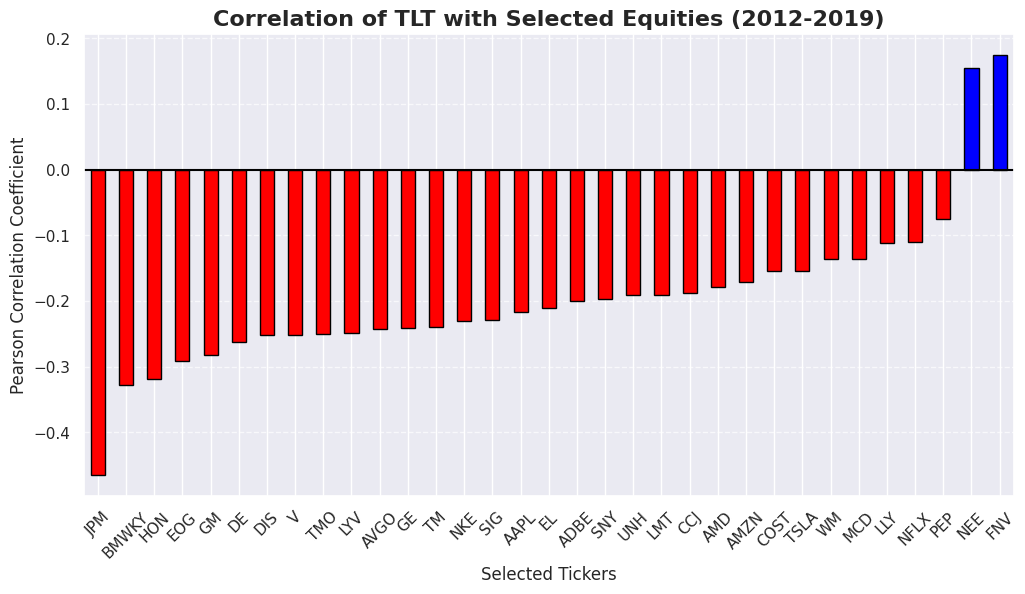

In [ ]:
corr_matrix = portfolio_returns.corr()

# TLT's correlation with the other assets
tlt_correlations = corr_matrix['TLT'].drop('TLT').sort_values()

# Average correlations of TLT with the rest of the portfolio
avg_tlt_corr = tlt_correlations.mean()

equity_returns = portfolio_returns.drop(columns=['TLT'])
equity_corr_matrix = equity_returns.corr()

avg_equity_corr = equity_corr_matrix.where(np.triu(np.ones(equity_corr_matrix.shape), k=1).astype(bool)).mean().mean()

print(f"Average correlation among Equities (2012-2019):  {avg_equity_corr:.4f}")
print(f"Average correlation of TLT vs Equities (2012-2019): {avg_tlt_corr:.4f}\n")

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'blue' for x in tlt_correlations]
tlt_correlations.plot(kind='bar', color=colors, edgecolor='black')

plt.title("Correlation of TLT with Selected Equities (2012-2019)", fontsize=16, fontweight='bold')
plt.xlabel("Selected Tickers")
plt.ylabel("Pearson Correlation Coefficient")
plt.axhline(0, color='black', linewidth=1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()



*   Average Equity Correlation (+0.2630): This proves that the stock market generally moves together. When the economy is good, most stocks go up. Therefore, adding any stock to the portfolio adds risk.

*   TLT vs. Equities Correlation (-0.1947): This proves that long-term government bonds move in the opposite direction of the stock market. Therefore, adding TLT to the portfolio subtracts risk.

Because the optimizer requires every asset to have an equal, positive risk contribution (and you can't have negative weights), it mathematically had to drop TLT to 0.

From the graph:


*   JPMorgan has the strongest negative correlation (-0.45) with TLT. This can be because banks make money when interest rates are high. But when interest rates go high, bond prices (TLT) crash.
*   NEE (Utilities): Utility stocks are famous for being "bond proxies." They pay high, steady dividends, so investors treat them similarly to bonds.
*   FNV (Gold): Gold is a "safe" asset. When the stock market crashes, investors panic and buy both Gold and US Treasuries (TLT).


Finally, the cause should be due to the Risk Parity contribution formula in the `portfolio_risk_contribution` function:

**rc = w * (cov @ w)**  -> **w_i (Covariance_Matrix @ weights)_i**

can be negative for negatively correlated assets, making equal positive risk contribution impossible.

In [ ]:
def optimize_portfolio_unbounded(returns_df):
    cov, assets = get_shrinked_cov(returns_df)
    n = len(assets)

    w0 = np.ones(n) / n
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

    bounds = [(None, None) for _ in range(n)]    # instead of (0,1) we have (None, None) so unbound

    result = minimize(
        risk_parity_objective,
        w0,
        args=(cov,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 5000}
    )

    weights = pd.Series(result.x, index=assets)
    return weights, cov

unbounded_weights, unb_cov = optimize_portfolio_unbounded(portfolio_returns)

name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()
unbounded_summary = pd.DataFrame({
    'Company': [name_mapping.get(t, t) for t in unbounded_weights.index],
    'Weight (%)': unbounded_weights * 100
}, index=unbounded_weights.index)

display(unbounded_summary.sort_values(by='Weight (%)', ascending=False).round(4))

,Company,Weight (%)
Ticker,,
NEE,NEXTERA_ENERGY,6.7350
FNV,FRANCO_NEVADA,5.9634
PEP,PEPSICO,5.5290
MCD,MCDONALDS,5.1215
WM,WASTE_MANAGEMENT,4.8404
COST,COSTCO,4.2693
LMT,LOCKHEED_MARTIN,4.1221
LLY,ELI_LILLY,3.9705
UNH,UNITEDHEALTH,3.5364


Upon running the unbounded optimization, the algorithm assigned a weight of -8.13% to TLT. This happens because of how Risk Parity defines risk contribution: Risk Contribution = Weight × Marginal Risk.

Because TLT is negatively correlated with our equity-heavy portfolio, its Marginal Risk is negative (adding it reduces overall portfolio volatility). However, the Risk Parity objective requires every asset to have an equal, positive risk contribution. The only way to achieve a positive risk contribution from an asset with negative marginal risk is to assign it a negative weight (Negative Weight × Negative Marginal Risk = Positive Risk Contribution).

Example: NEE went from 5.98% in the bounded portfolio up to 6.73% in the unbounded one. FNV went from 5.26% to 5.96%




---


---


Now, we calculate some **Portfolio Concentration Metrics** to quantify diversification.

*   **Herfindahl-Hirschman Index**: Measures concentration (lower is better, 1/N is equal-weighted).
*   **Shannon Entropy Index**: Measures the amount of 'information' or uncertainty (higher is better, \ln(N) is equal-weighted).

In [ ]:
def calculate_concentration_metrics(weights):
    # Ensure weights are a numpy array and positive
    w = np.array(weights)
    w = w[w > 0]

    # Herfindahl Index (HHI)
    hhi = np.sum(w**2)

    # Shannon Entropy
    entropy = -np.sum(w * np.log(w))

    # Theoretical limits for comparison
    n = len(w)
    hhi_min = 1/n
    entropy_max = np.log(n)

    return {
        'Herfindahl Index': hhi,
        'Shannon Entropy': entropy,
        'Max Possible Entropy (ln(N))': entropy_max,
        'Min Possible HHI (1/N)': hhi_min
    }

concentration_stats = calculate_concentration_metrics(final_weights)

The results for our weighted portfolio are:

In [ ]:
print("--- Portfolio Diversification Metrics ---")
for metric, value in concentration_stats.items():
    print(f"{metric:30}: {value:.4f}")

--- Portfolio Diversification Metrics ---
Herfindahl Index              : 0.0340
Shannon Entropy               : 3.4405
Max Possible Entropy (ln(N))  : 3.5264
Min Possible HHI (1/N)        : 0.0294


### 5.2. **Equal Weighted Portfolio Allocation**

Now, we repeat what we did before but try and allocate the same amount of money onto every asset.

In [ ]:
total_investment = 50000

selected_tickers = best_companies_df['Ticker'].tolist()
n_assets = len(selected_tickers)

equal_weights = np.ones(n_assets) / n_assets
equal_allocation_cash = total_investment / n_assets

name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

equal_portfolio_summary = pd.DataFrame({
    'Ticker': selected_tickers,
    'Company': [name_mapping.get(t, t) for t in selected_tickers],
    'Weight (%)': equal_weights * 100,
    'Cash Allocation ($)': equal_allocation_cash
})

print(f"--- EQUAL-WEIGHTED PORTFOLIO ALLOCATION FOR ${total_investment:,.2f} ---")
print(f"Investment per Asset: ${equal_allocation_cash:,.2f}\n")

display(equal_portfolio_summary.sort_values(by='Ticker'))

final_weights_equal = pd.Series(equal_weights, index=selected_tickers)
print(f"\nTotal Weight Check: {final_weights_equal.sum():.2f}")

--- EQUAL-WEIGHTED PORTFOLIO ALLOCATION FOR $50,000.00 ---
Investment per Asset: $1,470.59



,Ticker,Company,Weight (%),Cash Allocation ($)
19,AAPL,APPLE,2.941176,1470.588235
23,ADBE,ADOBE,2.941176,1470.588235
20,AMD,AMD,2.941176,1470.588235
21,AMZN,AMAZON,2.941176,1470.588235
18,AVGO,BROADCOM,2.941176,1470.588235
32,BMWKY,BMW,2.941176,1470.588235
17,CCJ,CAMECO,2.941176,1470.588235
11,COST,COSTCO,2.941176,1470.588235
28,DE,DEERE,2.941176,1470.588235
9,DIS,DISNEY,2.941176,1470.588235



Total Weight Check: 1.00


And the results of this method:

In [ ]:
concentration_stats_equal = calculate_concentration_metrics(final_weights_equal)

print("--- Portfolio Diversification Metrics ---")
for metric, value in concentration_stats_equal.items():
    print(f"{metric:30}: {value:.4f}")

--- Portfolio Diversification Metrics ---
Herfindahl Index              : 0.0294
Shannon Entropy               : 3.5264
Max Possible Entropy (ln(N))  : 3.5264
Min Possible HHI (1/N)        : 0.0294


In the next step, we will project our portfolio over the test set (market years 2022/2025) and observe the results. Both the **equal risk method** and the **equal cash allocation method** will be compared with the S&P 500 benchmark.

## 6. **Out-of-sample projection (Risk Parity)**

In this phase, we test our optimized Risk Parity portfolio on the test set.

First we have to convert the log returns to the return and select the choosen stocks

In [ ]:
# log return -> return
simple_test_returns = np.exp(test_returns) - 1
simple_test_returns.head()

Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA,BLK,BMWKY,BRK-B,CAT,CCJ,CL,CMCSA,COP,COST,CRM,CVX,DE,DIS,DUK,EL,EOG,F,FNV,GD,GE,GLD,GM,GOOGL,GS,HL,HMC,HON,IEF,INTC,JNJ,JPM,KO,LLY,LMT,LYV,MA,MCD,MDLZ,MDT,MRK,MS,MSFT,NEE,NEM,NFLX,NKE,NOC,NSANY,NVDA,ORCL,OXY,PAAS,PEP,PFE,PG,RTX,SCHW,SIG,SLB,SLV,SMH,SNY,TLT,TM,TMO,TSLA,UNH,UNP,USO,V,VNQ,VWAGY,WM,WMT,WPM,XLB,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,0.025004,-0.012079,-0.004744,-0.026157,0.044058,0.022118,0.001696,-0.003141,0.028179,0.032486,-0.004183,0.034731,0.005987,0.001258,0.041265,-0.008788,0.008146,0.022028,-0.001744,0.005234,0.016276,0.021056,0.012073,-0.013441,0.000243,0.026230,0.048146,-0.015836,-0.004845,0.018736,-0.015384,0.043323,0.000963,0.033407,-0.011495,0.013005,-0.008201,-0.009305,0.033204,0.002747,0.021156,0.001520,-0.016255,-0.002955,0.012115,0.032367,0.001902,-0.005127,0.025616,0.003001,0.020680,-0.004668,-0.018209,-0.016769,-0.008416,-0.012000,-0.003978,0.010406,0.024141,0.007912,0.071404,-0.026031,-0.004202,-0.040643,-0.004157,0.010574,0.019738,0.068827,0.059099,-0.015342,0.022054,0.011776,-0.026250,0.005342,-0.033451,0.135317,0.000279,-0.016512,0.008646,0.021780,-0.007844,0.030137,-0.024925,-0.000276,-0.025623,-0.013023,0.038405,0.006374
2022-01-04,-0.012692,-0.023518,-0.018374,0.019710,-0.038738,-0.016916,-0.022947,0.011458,0.032103,0.027759,0.006022,0.029803,0.025732,0.053526,0.040951,0.003310,-0.005942,0.043378,-0.004376,-0.028302,0.018196,0.060495,-0.006571,-0.000773,0.004240,0.045963,0.116674,0.002351,0.022125,0.032523,0.007367,0.074710,-0.004083,0.030734,0.000000,0.023248,0.010638,-0.000527,-0.001316,-0.002682,0.037910,0.016695,-0.018106,0.021532,-0.003467,0.011969,-0.000261,0.007276,0.002733,0.001821,0.040623,-0.017147,-0.010692,-0.009019,-0.010412,0.010445,0.029725,0.060762,-0.027589,0.010694,0.074694,-0.003701,0.001445,-0.037423,0.003499,0.035070,0.048974,0.025371,0.048549,0.006610,-0.005197,-0.019333,-0.004158,0.069247,-0.041742,-0.041833,-0.022657,0.017193,0.013861,0.004652,-0.001216,0.040891,0.009586,-0.018320,-0.002630,0.012300,0.037614,-0.000630
2022-01-05,-0.026600,-0.004493,-0.071426,-0.014213,-0.057264,-0.018893,-0.043019,-0.041615,-0.010656,-0.002621,-0.027747,0.005620,0.004505,0.007658,0.022843,0.004124,0.000598,-0.017149,-0.025362,-0.082826,0.006506,0.002047,-0.003467,0.002224,-0.042355,-0.018353,-0.026738,-0.041270,-0.008206,0.000000,-0.003008,-0.045634,-0.045876,-0.021719,-0.015504,-0.007460,0.009856,-0.004215,0.013737,0.006663,-0.018282,0.008293,-0.023088,-0.010635,-0.026922,-0.003969,-0.004916,0.014447,-0.003572,0.024283,-0.024746,-0.038388,-0.010476,-0.001655,-0.039973,-0.024881,-0.005038,0.018447,-0.057562,-0.026790,-0.047034,-0.027652,0.003406,0.020172,0.004527,-0.004999,-0.007225,-0.025791,0.000000,-0.015009,-0.034304,0.000201,-0.005428,-0.011246,0.000842,-0.053471,-0.002465,0.003016,-0.002878,-0.011058,-0.028619,-0.007346,-0.014973,0.013521,-0.029722,-0.000110,0.012437,-0.019393
2022-01-06,-0.016693,-0.000148,-0.000603,-0.038831,0.000588,-0.006711,0.023402,-0.009285,0.009164,-0.008119,0.004172,0.014809,0.010648,0.010193,-0.060381,-0.006571,0.005775,0.037541,-0.000218,0.006501,0.008509,0.011584,0.011019,-0.001640,-0.002022,0.020513,0.033813,-0.031959,0.006800,0.005837,-0.012244,0.002072,-0.000199,-0.004265,-0.041339,0.015716,-0.001137,-0.002470,0.002599,-0.003426,0.010624,-0.005264,-0.005064,-0.000391,0.015919,-0.009132,0.009357,-0.000445,-0.009810,-0.000634,0.017113,-0.007902,-0.044133,-0.027515,-0.025074,-0.007458,0.005772,0.020972,0.020794,0.002322,0.029865,-0.041171,0.000230,-0.014201,-0.008404,0.005470,0.016012,0.013990,0.023753,-0.023333,0.009928,-0.002414,0.002589,0.014217,0.003039,-0.021523,-0.040924,0.002769,0.026340,-0.001137,0.000895,-0.005631,0.006241,-0.002779,-0.045454,-0.012594,0.023521,-0.000964
2022-01-07,0.000989,0.003108,-0.006652,0.002600,-0.031050,-0.004288,-0.009199,-0.028068,0.008560,0.019684,-0.003596,-0.001652,0.020944,0.009910,0.04

In [ ]:
# Select choosen assets
test_assets = final_weights.index.tolist()
portfolio_test_returns = simple_test_returns[test_assets]
portfolio_test_returns

Ticker,TLT,FNV,NEE,PEP,TMO,UNH,LLY,SNY,LMT,DIS,LYV,COST,EL,NKE,WM,MCD,EOG,CCJ,AVGO,AAPL,AMD,AMZN,V,ADBE,NFLX,TSLA,SIG,JPM,DE,HON,GE,TM,BMWKY,GM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,-0.026250,-0.015836,-0.018209,-0.004202,-0.033451,0.000279,-0.016255,0.011776,-0.002955,0.012073,0.012115,-0.001744,0.000243,-0.012000,-0.024925,0.001902,0.026230,0.041265,-0.003141,0.025004,0.044058,0.022118,0.021780,-0.004744,-0.008416,0.135317,0.068827,0.021156,0.021056,-0.008201,0.018736,0.005342,0.034731,0.043323
2022-01-04,-0.004158,0.002351,-0.010692,0.001445,-0.041742,-0.022657,-0.018106,-0.019333,0.021532,-0.006571,-0.003467,-0.004376,0.004240,0.010445,0.009586,-0.000261,0.045963,0.040951,0.011458,-0.012692,-0.038738,-0.016916,0.004652,-0.018374,-0.010412,-0.041833,0.025371,0.037910,0.060495,0.010638,0.032523,0.069247,0.029803,0.074710
2022-01-05,-0.005428,-0.041270,-0.010476,0.003406,0.000842,-0.002465,-0.023088,0.000201,-0.010635,-0.003467,-0.026922,-0.025362,-0.042355,-0.024881,-0.014973,-0.004916,-0.018353,0.022843,-0.041615,-0.026600,-0.057264,-0.018893,-0.011058,-0.071426,-0.039973,-0.053471,-0.025791,-0.018282,0.002047,0.009856,0.000000,-0.011246,0.005620,-0.045634
2022-01-06,0.002589,-0.031959,-0.044133,0.000230,0.003039,-0.040924,-0.005064,-0.002414,-0.000391,0.011019,0.015919,-0.000218,-0.002022,-0.007458,0.006241,0.009357,0.020513,-0.060381,-0.009285,-0.016693,0.000588,-0.006711,-0.001137,-0.000603,-0.025074,-0.021523,0.013990,0.010624,0.011584,-0.001137,0.005837,0.014217,0.014809,0.002072
2022-01-07,-0.007188,0.005529,0.007462,0.001265,-0.021486,-0.023528,0.000656,0.011895,0.005978,0.005927,-0.029160,-0.024773,-0.001295,-0.025273,-0.006693,-0.009752,0.027638,0.041813,-0.028068,0.000989,-0.031050,-0.004288,-0.012696,-0.006652,-0.022104,-0.035447,-0.035343,0.009908,0.006084,0.023385,0.014507,0.003454,-0.001652,-0.009543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.001603,0.004935,-0.003123,-0.022917,0.007365,-0.001107,-0.004496,0.006038,-0.002109,0.007475,0.016579,0.005635,-0.009296,0.002097,0.003096,-0.017013,0.005511,0.018537,0.023049,0.005130,-0.000233,0.016241,0.003664,-0.014292,0.002896,-0.006486,0.010717,0.008790,-0.005461,-0.002347,0.002542,-0.001230,-0.002196,-0.003372
2025-12-24,0.006057,-0.000139,0.008272,0.000418,-0.001414,0.008559,0.004983,0.000828,0.006631,0.011129,0.008397,0.019970,-0.001486,0.046390,0.004629,0.008011,-0.001154,-0.000749,0.002576,0.005324,0.000651,0.001034,0.004980,0.001589,0.001497,-0.000330,0.013866,0.009941,0.002638,0.007315,0.003867,-0.011449,-0.001926,0.001571
2025-12-26,-0.003294,0.007367,-0.000497,0.000278,0.002797,0.012974,0.000715,0.002275,-0.005600,-0.008036,0.003441,0.001709,0.001582,0.015500,-0.001175,-0.008458,-0.003562,-0.005357,0.005454,-0.001497,-0.000232,0.000602,-0.000394,0.002323,0.008864,-0.021034,-0.020687,-0.003828,0.003188,0.002234,-0.005083,-0.000508,0.004135,0.002172


Now we have to find the daily returns and the cumulative return

In [ ]:
# Daily return
portfolio_daily_returns_rp = portfolio_test_returns.dot(final_weights) # -> these are the weight we found in the previous step
portfolio_daily_returns_rp

,0
Date,
2022-01-03,0.006919
2022-01-04,0.006575
2022-01-05,-0.016873
2022-01-06,-0.005336
2022-01-07,-0.003463
...,...
2025-12-23,0.000360
2025-12-24,0.005425
2025-12-26,-0.000011


In [ ]:
# Cumulative return starting from our initial investment of 50000$
portfolio_cumulative_rp = (1 + portfolio_daily_returns_rp).cumprod() * total_investment # -> +1 to have return: 1+0.05(5% return)=1.05
portfolio_cumulative_rp

,0
Date,
2022-01-03,50345.935196
2022-01-04,50676.978387
2022-01-05,49821.930069
2022-01-06,49556.103271
2022-01-07,49384.470282
...,...
2025-12-23,76964.135885
2025-12-24,77381.647461
2025-12-26,77380.757773


To see the real performance of our portfolio we have to compare it to our benchmark (S&P500). We have to perform the same operaion as before

In [ ]:
# Daily return benchmark
benchmark_daily_returns = simple_test_returns[BENCHMARK]
# Cumulative return benchmark
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() * total_investment

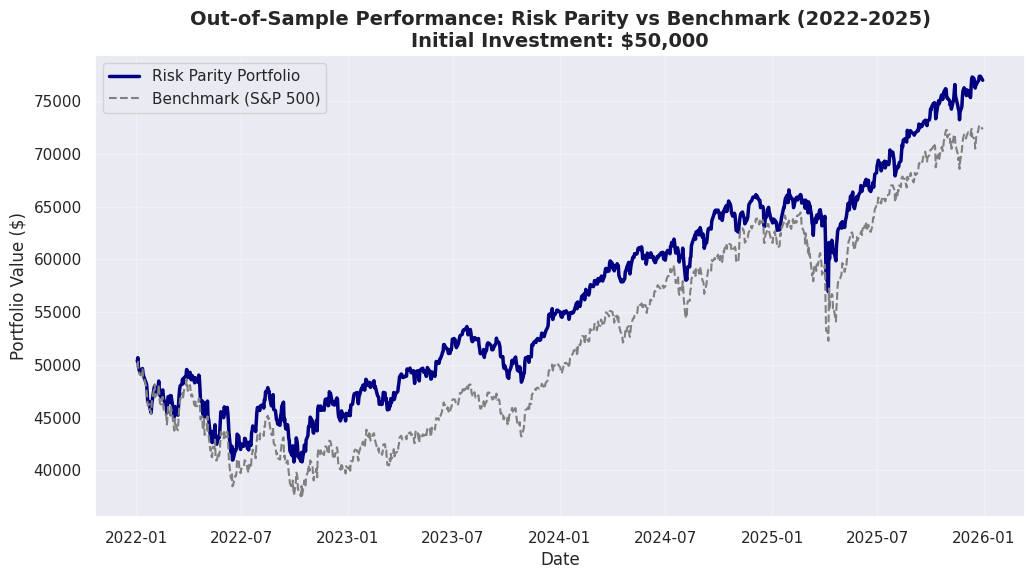

--- TEST SET PERFORMANCE SUMMARY ---
Final Portfolio Value:   $77,001.38
Final Benchmark Value:   $72,345.57
Total Portfolio Return:  54.00%
Total Benchmark Return:  44.69%


In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative_rp.index, portfolio_cumulative_rp, label='Risk Parity Portfolio', linewidth=2.5, color='navy')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label=f'Benchmark (S&P 500)', linewidth=1.5, linestyle='--', color='gray')

plt.title(f"Out-of-Sample Performance: Risk Parity vs Benchmark (2022-2025)\nInitial Investment: ${total_investment:,.0f}", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

# Performance Summary
test_return_total_rp = (portfolio_cumulative_rp.iloc[-1] / total_investment - 1) * 100
bench_return_total = (benchmark_cumulative.iloc[-1] / total_investment - 1) * 100

print(f"--- TEST SET PERFORMANCE SUMMARY ---")
print(f"Final Portfolio Value:   ${portfolio_cumulative_rp.iloc[-1]:,.2f}")
print(f"Final Benchmark Value:   ${benchmark_cumulative.iloc[-1]:,.2f}")
print(f"Total Portfolio Return:  {test_return_total_rp:.2f}%")
print(f"Total Benchmark Return:  {bench_return_total:.2f}%")

Our portfolio outperformed the Beanchmark portfolio in our test period! Starting from an initial investment of 50000\$ our portfolio has a final value of 77,001.38\$, nearly 5000$ more than the if we did the initial investment in the S&P500.
In particular, the portfolio return is of 54.00%, meanwhile the benchmark return is of 44.69\%.

## 7. **Results evaluation**

In [ ]:
def calculate_summary_metrics(asset_returns, market_returns, rf_rate=RISK_FREE_RATE):
    """
    Calculate risk metrics for the test period
    """
    cum_returns = (1 + asset_returns).cumprod()
    drawdowns = compute_drawdowns(cum_returns)

    variance = asset_returns.var() * TRADING_DAYS
    std_dev = asset_returns.std() * np.sqrt(TRADING_DAYS)
    var95 = historical_var(asset_returns, VAR_CONFIDENCE)
    cvar95 = historical_cvar(asset_returns, VAR_CONFIDENCE)
    beta = compute_beta(asset_returns, market_returns)
    expected_return = asset_returns.mean() * TRADING_DAYS
    skewness_value = skew(asset_returns)
    kurtosis_value = kurtosis(asset_returns)
    max_drawdown = drawdowns.min()
    avg_drawdown = drawdowns[drawdowns < 0].mean()
    downside_risk = semi_std_dev(asset_returns)
    sharpe = (expected_return - rf_rate) / std_dev if std_dev != 0 else np.nan

    return {
        'Expected Return (Ann)': expected_return,
        'Volatility (Ann)': std_dev,
        'Sharpe Ratio': sharpe,
        'Beta': beta,
        'VaR 95%': var95,
        'CVaR 95%': cvar95,
        'Max Drawdown': max_drawdown,
        'Avg Drawdown': avg_drawdown,
        'Skewness': skewness_value,
        'Kurtosis': kurtosis_value
    }

# Metrics for Risk Parity and Benchmark
portfolio_stats_rp = calculate_summary_metrics(portfolio_daily_returns_rp, benchmark_daily_returns)
benchmark_stats = calculate_summary_metrics(benchmark_daily_returns, benchmark_daily_returns)

# Comparison Table
comparison_df = pd.DataFrame({
    'Risk Parity Portfolio': portfolio_stats_rp,
    'S&P 500 Benchmark': benchmark_stats
}).T

display(comparison_df.style.format({
    'Expected Return (Ann)': '{:.2%}',
    'Volatility (Ann)': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Beta': '{:.2f}',
    'VaR 95%': '{:.2%}',
    'CVaR 95%': '{:.2%}',
    'Max Drawdown': '{:.2%}',
    'Avg Drawdown': '{:.2%}',
    'Skewness': '{:.2f}',
    'Kurtosis': '{:.2f}'
}))

,Expected Return (Ann),Volatility (Ann),Sharpe Ratio,Beta,VaR 95%,CVaR 95%,Max Drawdown,Avg Drawdown,Skewness,Kurtosis
Risk Parity Portfolio,12.14%,16.02%,0.63,0.84,-1.47%,-2.27%,-19.54%,-4.91%,0.16,6.47
S&P 500 Benchmark,10.88%,17.81%,0.50,1.00,-1.71%,-2.59%,-25.43%,-8.14%,0.19,7.09


Our portfolio expected annual return is higher than the benchmark, as previously observed. From the volatility values, we can also see that the portfolio exhibits lower risk, with an annualized volatility of 16.02% compared to 17.81% for the S&P 500.

This favorable risk-return profile is further confirmed by the Sharpe Ratio, which is higher for the Risk Parity portfolio (0.63 versus 0.50). This indicates that the portfolio generates greater returns for each unit of risk taken.

The portfolio also demonstrates lower market sensitivity, as evidenced by its beta of 0.84. This suggests that its performance is less dependent on overall market movements than the benchmark.

From a downside risk perspective, both VaR and CVaR show smaller potential losses for the portfolio. In addition, the maximum drawdown is significantly lower (-19.54% versus -25.43%), indicating that the portfolio experienced a less severe peak-to-trough decline during the test period. The average drawdown is also notably smaller, suggesting that losses were generally more contained over time.

Finally, the portfolio exhibits slightly lower kurtosis, indicating a reduced exposure to extreme return events.


## 8. **Comparison with the equal split situation (Risk Parity vs. Equal-Weighted vs. Benchmark)**

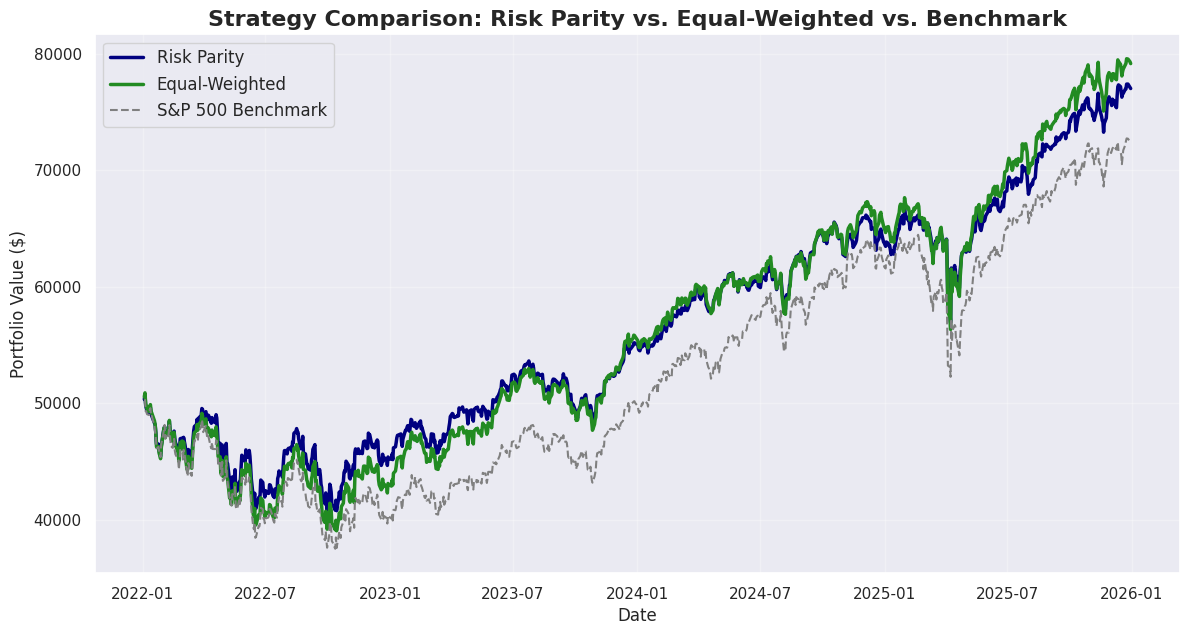

In [ ]:
# Daily Returns for the Equal-Weighted Portfolio
portfolio_daily_returns_eq = portfolio_test_returns.dot(final_weights_equal)

# Cumulative growth
portfolio_cumulative_eq = (1 + portfolio_daily_returns_eq).cumprod() * total_investment

# Plot all three strategies together
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cumulative_rp.index, portfolio_cumulative_rp, label='Risk Parity', linewidth=2.5, color='navy')
plt.plot(portfolio_cumulative_eq.index, portfolio_cumulative_eq, label='Equal-Weighted', linewidth=2.5, color='forestgreen')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='S&P 500 Benchmark', linewidth=1.5, linestyle='--', color='gray')

plt.title("Strategy Comparison: Risk Parity vs. Equal-Weighted vs. Benchmark", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# We use the same fuction as before to calulate the metrics
portfolio_stats_eq = calculate_summary_metrics(portfolio_daily_returns_eq, benchmark_daily_returns)

comparison_final_df = pd.DataFrame({
    'Risk Parity': portfolio_stats_rp,
    'Equal-Weighted': portfolio_stats_eq,
    'S&P 500 Benchmark': benchmark_stats
}).T

display(comparison_final_df.style.format({
    'Expected Return (Ann)': '{:.2%}',
    'Volatility (Ann)': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Beta': '{:.2f}',
    'VaR 95%': '{:.2%}',
    'CVaR 95%': '{:.2%}',
    'Max Drawdown': '{:.2%}',
    'Avg Drawdown': '{:.2%}',
    'Skewness': '{:.2f}',
    'Kurtosis': '{:.2f}'
}))

,Expected Return (Ann),Volatility (Ann),Sharpe Ratio,Beta,VaR 95%,CVaR 95%,Max Drawdown,Avg Drawdown,Skewness,Kurtosis
Risk Parity,12.14%,16.02%,0.63,0.84,-1.47%,-2.27%,-19.54%,-4.91%,0.16,6.47
Equal-Weighted,13.07%,17.46%,0.63,0.93,-1.68%,-2.48%,-23.25%,-6.25%,0.23,6.57
S&P 500 Benchmark,10.88%,17.81%,0.50,1.00,-1.71%,-2.59%,-25.43%,-8.14%,0.19,7.09


The Equal-Weighted portfolio achieved the highest expected annual return (13.07%), followed by the Risk Parity portfolio (12.14%), while the S&P 500 benchmark delivered the lowest return (10.88%). However, return alone does not provide a complete picture, as it must be evaluated alongside the level of risk undertaken.

In terms of volatility, the Risk Parity portfolio exhibited the lowest annualized volatility (16.02%), compared to 17.46% for the Equal-Weighted portfolio and 17.81% for the benchmark. Despite generating a slightly lower return than the Equal-Weighted strategy, the Risk Parity portfolio achieved the same Sharpe Ratio (0.63), indicating that the extra return of the Equal-Weighted portfolio is roughly justified by its extra volatility. Both portfolios substantially outperformed the benchmark, whose Sharpe Ratio was only 0.50.

The beta values of 0.84 further emphasize the defensive characteristics of the Risk Parity approach. It was less sensitive to market movements than both the Equal-Weighted portfolio (0.93) and the benchmark (1.00). This suggests that the Risk Parity portfolio was able to reduce market exposure while still maintaining competitive returns.

The downside risk metrics tell a similar story. The Risk Parity portfolio recorded the least severe VaR (-1.47%) and CVaR (-2.27%), indicating smaller expected losses during both normal adverse market conditions and extreme downside events. The Equal-Weighted portfolio performed better than the benchmark but remained riskier than the Risk Parity strategy according to both measures.

Drawdown analysis also favors the Risk Parity portfolio. It experienced the smallest maximum drawdown (-19.54%), lower than the Equal-Weighted portfolio (-23.25%) and the S&P 500 benchmark (-25.43%). Similarly, its average drawdown (-4.91%) was lower than those of the Equal-Weighted portfolio (-6.25%) and the benchmark (-8.14%), indicating more stable performance throughout the test period.

Finally, all three portfolios exhibit slightly positive skewness, suggesting a tendency toward occasional large positive returns. The Risk Parity portfolio shows the lowest kurtosis (6.47), followed closely by the Equal-Weighted portfolio (6.57), while the benchmark exhibits the highest kurtosis (7.09). This indicates that both portfolio strategies were somewhat less exposed to extreme return events than the market benchmark.


## 9.  **Stock Profit and Loss Summary: How did we beat the benchmark?**

In [ ]:
# Returns
bench_tot_return = (1 + simple_test_returns[BENCHMARK]).cumprod().iloc[-1] - 1
stock_tot_returns = (1 + simple_test_returns[test_assets]).cumprod().iloc[-1] - 1

# Weights and Dollar Allocations
weights_rp = pd.Series(final_weights, index=test_assets)
weights_eq = pd.Series(final_weights_equal, index=test_assets)

# Dollar Profits
profit_rp_dollars = (weights_rp * total_investment) * stock_tot_returns
profit_eq_dollars = (weights_eq * total_investment) * stock_tot_returns

In [ ]:
name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

stock_df = pd.DataFrame({
    'Company': [name_mapping.get(t, t) for t in selected_tickers],
    'Stock Return (%)': stock_tot_returns * 100,
    'vs. S&P 500 (%)': (stock_tot_returns - bench_tot_return) * 100,
    'RP Weight (%)': weights_rp * 100,
    'RP Profit ($)': profit_rp_dollars,
    'EQ Weight (%)': weights_eq * 100,
    'EQ Profit ($)': profit_eq_dollars
}, index=selected_tickers)

stock_df = stock_df.sort_values(by='RP Profit ($)', ascending=False)

print(f"--- COMPARISON (Initial: ${total_investment:,.2f}) ---")
print(f"Total Profit (Risk Parity) : ${profit_rp_dollars.sum():,.2f}")
print(f"Total Profit (Equal Weight): ${profit_eq_dollars.sum():,.2f}")
print(f"Total Profit (S&P 500)     : ${(total_investment * bench_tot_return):,.2f}")
print("-" * 50)

# Colour style function
def color_negative_red(val):
    color = 'red' if val < 0 else 'green'
    return f'color: {color}'

# Display
print("(Sorted by Risk Parity Profit descending)")

stock_colour = stock_df.style.format({
    'Stock Return (%)': '{:.2f}%',
    'vs. S&P 500 (%)': '{:+.2f}%',
    'RP Weight (%)': '{:.2f}%',
    'RP Profit ($)': '${:,.2f}',
    'EQ Weight (%)': '{:.2f}%',
    'EQ Profit ($)': '${:,.2f}'
}).map(color_negative_red, subset=['vs. S&P 500 (%)', 'RP Profit ($)', 'EQ Profit ($)'])

display(stock_colour)

--- COMPARISON (Initial: $50,000.00) ---
Total Profit (Risk Parity) : $29,794.35
Total Profit (Equal Weight): $31,940.21
Total Profit (S&P 500)     : $22,345.57
--------------------------------------------------
(Sorted by Risk Parity Profit descending)


,Company,Stock Return (%),vs. S&P 500 (%),RP Weight (%),RP Profit ($),EQ Weight (%),EQ Profit ($)
GE,GENERAL ELECTRIC,440.22%,+395.52%,2.80%,"$6,163.42",2.94%,"$6,473.76"
LLY,ELI_LILLY,305.77%,+261.08%,3.66%,"$5,594.68",2.94%,"$4,496.60"
AVGO,BROADCOM,467.59%,+422.89%,2.01%,"$4,694.32",2.94%,"$6,876.25"
CCJ,CAMECO,323.02%,+278.33%,2.26%,"$3,651.26",2.94%,"$4,750.32"
JPM,JPMORGAN_CHASE,126.85%,+82.16%,2.63%,"$1,667.14",2.94%,"$1,865.51"
FNV,FRANCO_NEVADA,56.24%,+11.55%,5.26%,"$1,479.10",2.94%,$827.05
COST,COSTCO,59.94%,+15.25%,3.95%,"$1,183.30",2.94%,$881.43
LMT,LOCKHEED_MARTIN,52.90%,+8.21%,3.83%,"$1,011.93",2.94%,$777.93
WM,WASTE_MANAGEMENT,41.68%,-3.01%,4.47%,$930.75,2.94%,$612.98
V,VISA,68.17%,+23.48%,2.62%,$894.36,2.94%,"$1,002.49"




*   **Total Return (%)**: the actual profit or loss of that specific stock between 2022 and 2025
*   **vs. S&P 500 (%)**: stock's Total Return and subtracts the S&P 500's return (44.69%)


---


From this table, we can see that 5 different assets have done a huge profit generating nearly the same profit of the whole S&P500.
It's important to notice that we have differences in gains from the Risk Partity to the Equal-Weighted portfolio. For example, since semicnducors are higly volative, the Risk Parity reduced the weight of AVGO to 2.01\%, missing nearly 2000$ in profit. But, in the same way, LLY went up 305\%. Becuase pharmaceuticals are historically more stable, Risk Parity gave it  3.66\% weight (gaining nealy 1000\$ from the Equal-Weight).

Also, the TLT crashed by -31.72\%. The Risk Parity approach assigned it a weight of 0.00\% avoiding the loss of 466.45\$ of the Equal-Weighted approach.

Finally, for our losses, we can notice, for example, at UNH (UnitedHealth) and PEP (Pepsi). The Risk Parity approach assigned an higher weight (3.29\% and 5.07\%) to these two companies because of their low volatility. Unfortunately, during 2022-2025, they both lost money. Because Risk Parity put more money into them, we lost more dollars here than the Equal-Weight strategy did.


## **10. Frequency Analysis: Daily vs. Weekly vs. Monthly**

By lowering the sampling frequency from Daily to Monthly, the model successfully filters out short-term market microstructure noise (such as algorithmic trading anomalies and daily sentiment overreactions). This allows the clustering algorithm to isolate the true underlying macroeconomic signal, resulting in a more robust covariance matrix and superior Risk Parity allocation.

In [ ]:
def analyze_frequency(raw_prices, freq_name, resample_rule, trading_days):

    # Resample and calculate returns
    if resample_rule:   # W-FRI -> weekly | ME -> monthly | None -> daily
        prices_freq = raw_prices.resample(resample_rule).last().dropna(how='all')
    else:
        prices_freq = raw_prices.copy()

    # Log trans and train/test
    log_ret = np.log(prices_freq / prices_freq.shift(1)).dropna()
    train_ret = log_ret.loc[:"2019-12-31"]
    test_ret = log_ret.loc["2022-01-01":]

    # Train Metrics for Asset Selection
    results = []
    for ticker in train_ret.columns:
        asset_ret = train_ret[ticker].dropna()
        if len(asset_ret) < 10: continue
        downside = asset_ret[asset_ret < 0]
        downside_risk = (downside.std() * np.sqrt(trading_days)) if len(downside) > 0 else np.nan
        sortino = sortino_ratio(asset_ret.mean() * trading_days, downside_risk)
        results.append({"Ticker": ticker, "Sortino": sortino})

    df_res = pd.DataFrame(results).dropna()

    #### Dynamic Clustering ####
    X = train_ret[df_res['Ticker']].T
    corr_matrix = X.T.corr()
    dist_matrix = np.sqrt(0.5 * (1 - corr_matrix).clip(lower=0))
    dist_1d = squareform(dist_matrix.values, force='tovector')
    dist_2d = squareform(dist_1d)

    Z = linkage(dist_1d, method="ward")

    best_k = 5
    best_silhouette = -1

    # Iterate to find optimal number of clusters
    for k in range(5, min(45, len(X))):
        labels_temp = fcluster(Z, k, criterion="maxclust")
        if 1 < len(set(labels_temp)) < len(X):
            score = silhouette_score(dist_2d, labels_temp, metric="precomputed")
            if score > best_silhouette:
                best_silhouette = score
                best_k = k

    print(f" -> Optimal clusters found for {freq_name}: {best_k} (Silhouette Score: {best_silhouette:.4f})")

    labels = fcluster(Z, best_k, criterion="maxclust")
    df_res['Cluster'] = labels

    # Pick Best Assets & Optimize
    best_tickers = df_res.loc[df_res.groupby('Cluster')['Sortino'].idxmax()]['Ticker'].tolist()
    weights, _ = optimize_portfolio(train_ret[best_tickers])

    # Out-of-Sample Testing
    simple_test_returns = np.exp(test_ret) - 1
    portfolio_test_returns = simple_test_returns[best_tickers].dot(weights)
    test_cumulative = (1 + portfolio_test_returns).cumprod()
    test_cumulative_dollars = test_cumulative * 50000

    # Calculate Test Metrics
    expected_return = portfolio_test_returns.mean() * trading_days
    volatility = portfolio_test_returns.std() * np.sqrt(trading_days)
    sharpe = (expected_return - RISK_FREE_RATE) / volatility
    max_dd = compute_drawdowns(test_cumulative).min()

    metrics = {
        'Expected Return (Ann)': expected_return,
        'Volatility (Ann)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'VaR 95%': historical_var(portfolio_test_returns, 0.95),
        'CVaR 95%': historical_cvar(portfolio_test_returns, 0.95),
        'Skewness': skew(portfolio_test_returns),
        'Kurtosis': kurtosis(portfolio_test_returns),
        'Total Return 2022-2025': (test_cumulative_dollars.iloc[-1] / 50000 - 1)
    }

    return freq_name, metrics, test_cumulative_dollars, weights, set(best_tickers)

In [ ]:
# Setup Data and Configurations
raw_prices = yf.download(all_assets, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)["Close"]
raw_prices = raw_prices.dropna(axis=1, how="all").dropna(subset=[BENCHMARK]).ffill().dropna(axis=1, how="any")

frequency_configs = [
    {'name': 'Daily', 'rule': None, 'days': 252},
    {'name': 'Weekly', 'rule': 'W-FRI', 'days': 52},
    {'name': 'Monthly', 'rule': 'ME', 'days': 12}
]

# Run Pipeline
all_metrics = {}
all_curves = {}
all_weights = {}
all_sets = {}

print("\nClustering results:")
for config in frequency_configs:
    fname, metrics, curve, weights, asset_set = analyze_frequency(
        raw_prices, config['name'], config['rule'], config['days']
    )
    all_metrics[fname] = metrics
    all_curves[fname] = curve
    all_weights[fname] = weights
    all_sets[fname] = asset_set


Clustering results:
 -> Optimal clusters found for Daily: 34 (Silhouette Score: 0.1420)
 -> Optimal clusters found for Weekly: 36 (Silhouette Score: 0.1319)
 -> Optimal clusters found for Monthly: 32 (Silhouette Score: 0.1353)


The optimal number of clusters adapts to the timeframe (Daily: 34, Weekly: 36, Monthly: 32). Because monthly data filters out day-to-day market noise, assets naturally group together into slightly larger, more cohesive macroeconomic sectors, reducing the optimal cluster count to 32.

In [ ]:
# Raw correlation matrices for each frequency
for config in frequency_configs:
    print(f"\n--- {config['name']} Correlation Matrix (First 10 stocks) ---")

    if config['rule']:
        p_freq = raw_prices.resample(config['rule']).last().dropna(how='all')
    else:
        p_freq = raw_prices.copy()

    log_ret = np.log(p_freq / p_freq.shift(1)).dropna()
    train_ret = log_ret.loc[:"2019-12-31"]
    corr_matrix = train_ret.corr()

    avg_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).mean().mean()
    print(f"{config['name']} Average Correlation: {avg_corr:.4f}")

    display(corr_matrix.iloc[:10, :10])


--- Daily Correlation Matrix (First 10 stocks) ---
Daily Average Correlation: 0.2791


Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA
Ticker,,,,,,,,,,
AAPL,1.000000,0.333469,0.376845,0.064640,0.256671,0.358981,0.382971,0.454585,0.322524,0.337101
ABT,0.333469,1.000000,0.441415,0.005945,0.263729,0.345067,0.396022,0.338627,0.455468,0.414822
ADBE,0.376845,0.441415,1.000000,0.051166,0.303388,0.475115,0.454397,0.378070,0.406641,0.388296
AEM,0.064640,0.005945,0.051166,1.000000,0.043037,0.035389,0.048898,0.039375,-0.003753,-0.000360
AMD,0.256671,0.263729,0.303388,0.043037,1.000000,0.249983,0.300067,0.298918,0.275853,0.243794
AMZN,0.358981,0.345067,0.475115,0.035389,0.249983,1.000000,0.338385,0.336447,0.350734,0.326776
ASML,0.382971,0.396022,0.454397,0.048898,0.300067,0.338385,1.000000,0.475926,0.381297,0.372205
AVGO,0.454585,0.338627,0.378070,0.039375,0.298918,0.336447,0.475926,1.000000,0.352346,0.325517
AXP,0.322524,0.455468,0.406641,-0.003753,0.275853,0.350734,0.381297,0.352346,1.000000,0.409180



--- Weekly Correlation Matrix (First 10 stocks) ---
Weekly Average Correlation: 0.2634


Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA
Ticker,,,,,,,,,,
AAPL,1.000000,0.353762,0.343237,0.037859,0.252760,0.323008,0.342789,0.417566,0.281212,0.254188
ABT,0.353762,1.000000,0.421983,-0.064765,0.307644,0.417309,0.330004,0.303826,0.493601,0.386101
ADBE,0.343237,0.421983,1.000000,-0.026135,0.303496,0.488823,0.383320,0.320022,0.388563,0.353134
AEM,0.037859,-0.064765,-0.026135,1.000000,-0.041287,-0.018244,0.002966,-0.009498,-0.070024,-0.099789
AMD,0.252760,0.307644,0.303496,-0.041287,1.000000,0.252165,0.305486,0.316016,0.349518,0.234234
AMZN,0.323008,0.417309,0.488823,-0.018244,0.252165,1.000000,0.366502,0.282541,0.348422,0.341725
ASML,0.342789,0.330004,0.383320,0.002966,0.305486,0.366502,1.000000,0.438598,0.262224,0.281626
AVGO,0.417566,0.303826,0.320022,-0.009498,0.316016,0.282541,0.438598,1.000000,0.268947,0.213562
AXP,0.281212,0.493601,0.388563,-0.070024,0.349518,0.348422,0.262224,0.268947,1.000000,0.398575



--- Monthly Correlation Matrix (First 10 stocks) ---
Monthly Average Correlation: 0.2380


Ticker,AAPL,ABT,ADBE,AEM,AMD,AMZN,ASML,AVGO,AXP,BA
Ticker,,,,,,,,,,
AAPL,1.000000,0.379106,0.379478,-0.028397,0.219627,0.303171,0.318674,0.330473,0.250519,0.178107
ABT,0.379106,1.000000,0.417559,-0.048122,0.347724,0.450672,0.387501,0.287391,0.475460,0.392819
ADBE,0.379478,0.417559,1.000000,-0.044034,0.344529,0.556844,0.413768,0.376207,0.452478,0.343390
AEM,-0.028397,-0.048122,-0.044034,1.000000,-0.084209,0.045671,-0.002147,0.040125,-0.193537,-0.075790
AMD,0.219627,0.347724,0.344529,-0.084209,1.000000,0.388642,0.272727,0.313816,0.456070,0.337875
AMZN,0.303171,0.450672,0.556844,0.045671,0.388642,1.000000,0.371817,0.195271,0.362056,0.402095
ASML,0.318674,0.387501,0.413768,-0.002147,0.272727,0.371817,1.000000,0.282772,0.308455,0.265401
AVGO,0.330473,0.287391,0.376207,0.040125,0.313816,0.195271,0.282772,1.000000,0.276640,0.188905
AXP,0.250519,0.475460,0.452478,-0.193537,0.456070,0.362056,0.308455,0.276640,1.000000,0.422598


In [ ]:
# Calculate benchmark metrics for comparison
bench_ret = np.exp(np.log(raw_prices[BENCHMARK] / raw_prices[BENCHMARK].shift(1)).dropna().loc["2022-01-01":]) - 1
bench_cum = (1 + bench_ret).cumprod()

bench_metrics = {
    'Expected Return (Ann)': bench_ret.mean() * 252,
    'Volatility (Ann)': bench_ret.std() * np.sqrt(252),
    'Sharpe Ratio': (bench_ret.mean() * 252 - RISK_FREE_RATE) / (bench_ret.std() * np.sqrt(252)),
    'Max Drawdown': compute_drawdowns(bench_cum).min(),
    'VaR 95%': historical_var(bench_ret, 0.95),
    'CVaR 95%': historical_cvar(bench_ret, 0.95),
    'Skewness': skew(bench_ret),
    'Kurtosis': kurtosis(bench_ret),
    'Total Return 2022-2025': (bench_cum.iloc[-1] - 1)
}

# Combine metrics
all_metrics_with_bench = all_metrics.copy()
all_metrics_with_bench['S&P 500 (Bench)'] = bench_metrics
metrics_df = pd.DataFrame(all_metrics_with_bench).T

display(metrics_df.style.format({
    'Expected Return (Ann)': '{:.2%}',
    'Volatility (Ann)': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Max Drawdown': '{:.2%}',
    'VaR 95%': '{:.2%}',
    'CVaR 95%': '{:.2%}',
    'Skewness': '{:.2f}',
    'Kurtosis': '{:.2f}',
    'Total Return 2022-2025': '{:.2%}'
}))

,Expected Return (Ann),Volatility (Ann),Sharpe Ratio,Max Drawdown,VaR 95%,CVaR 95%,Skewness,Kurtosis,Total Return 2022-2025
Daily,12.14%,16.02%,0.63,-19.54%,-1.47%,-2.27%,0.16,6.47,54.00%
Weekly,12.09%,15.54%,0.65,-18.25%,-3.17%,-4.41%,-0.07,1.02,54.82%
Monthly,14.91%,14.31%,0.90,-15.87%,-6.38%,-7.20%,-0.33,-0.51,73.85%
S&P 500 (Bench),10.88%,17.81%,0.50,-25.43%,-1.71%,-2.59%,0.19,7.09,44.69%


By concentrating capital into 32 assets, the Monthly portfolio generated a 73.85% Total Return, outperforming the Daily portfolio (54.00%). All three of our Risk Parity portfolios successfully outperformed the benchmark, but the Monthly portfolio emerged as the best strategy:


*   **Risk-Adjusted Returns**: Moving from Daily to Monthly data, the "noise" of the market is filtered out. This causes the annualized volatility to drop, from 16.02% (Daily) to 14.31% (Monthly). Because the Monthly portfolio generated the highest expected return (14.91%) with the lowest volatility, it achieved a Sharpe Ratio of 0.90, vastly superior to the benchmark's 0.50.

*   **Drawdown**: The Monthly portfolio experienced the minimum drawdown (-15.87%) compared to the Daily portfolio (-19.54%) and the S&P 500 (-25.43%). By evaluating assets on a 30-day basis, the algorithm ignored short-term mid-month crashes.

*    **VaR and CVaR**: These metrics are time-dependent; the scale of potential losses naturally increases as the time horizon extends from daily to monthly intervals, which explains the larger VaR and CVaR values for the monthly portfolio. However, relative to their respective time horizons, all three strategies exhibit highly controlled downside risk and superior risk-adjusted performance compared to the S&P 500 benchmark.

*    **Kurtosis & Skewness**: The Daily data exhibits high kurtosis (6.47), meaning daily returns have frequent extreme positive or negative days. The Monthly data, however, has a negative kurtosis (-0.51). This indicates a platykurtic distribution: the returns are highly consistent and clustered closer to the mean, with far fewer extreme, unpredictable swings.





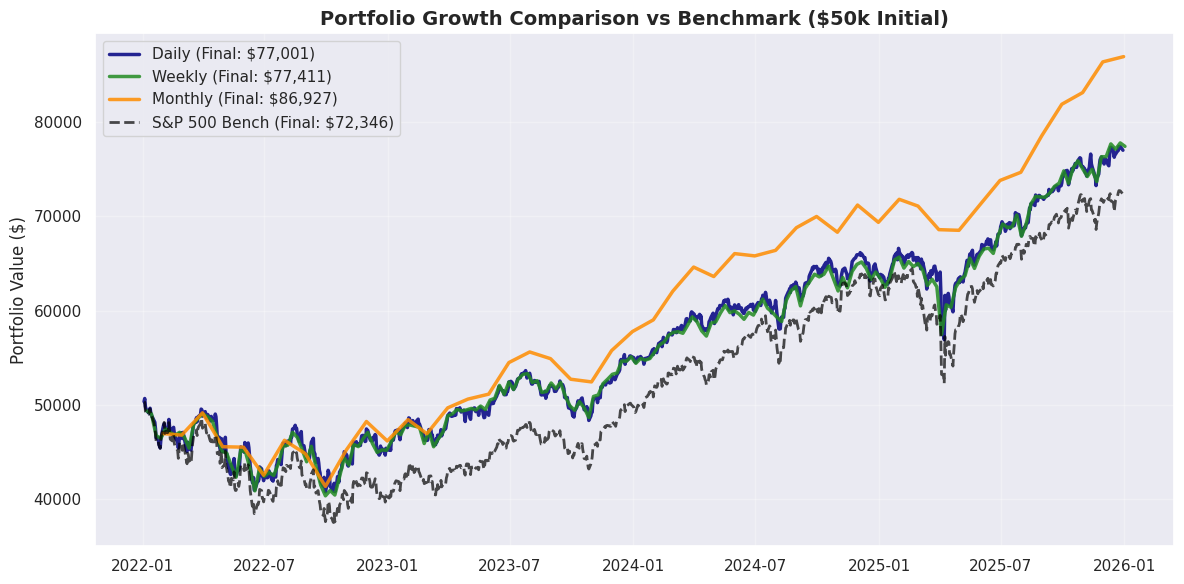

In [ ]:
# Plots
plt.figure(figsize=(12, 6))
colors = {'Daily': 'navy', 'Weekly': 'forestgreen', 'Monthly': 'darkorange'}

# Plot Portfolio Frequencies
for fname, curve in all_curves.items():
    plt.plot(curve.index, curve, label=f'{fname} (Final: ${curve.iloc[-1]:,.0f})',
                 linewidth=2.5, color=colors[fname], alpha=0.85)

# Plot Benchmark
bench_curve = (1 + bench_ret).cumprod() * 50000
plt.plot(bench_curve.index, bench_curve, label=f'S&P 500 Bench (Final: ${bench_curve.iloc[-1]:,.0f})',
         linewidth=2, color='black', linestyle='--', alpha=0.7)

plt.title("Portfolio Growth Comparison vs Benchmark ($50k Initial)", fontsize=14, fontweight='bold')
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Weights comparison
name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

# Get union of all tickers selected across all frequencies to prevent disappearing stocks
all_selected_tickers = list(all_sets['Daily'] | all_sets['Weekly'] | all_sets['Monthly'])

comparison_weights = pd.DataFrame({
    'Company': [name_mapping.get(t, t) for t in all_selected_tickers],
    'Daily (%)': pd.Series(all_weights['Daily'], index=all_selected_tickers) * 100,
    'Weekly (%)': pd.Series(all_weights['Weekly'], index=all_selected_tickers) * 100,
    'Monthly (%)': pd.Series(all_weights['Monthly'], index=all_selected_tickers) * 100
}, index=all_selected_tickers).fillna(0)

comparison_weights = comparison_weights[comparison_weights[['Daily (%)', 'Weekly (%)', 'Monthly (%)']].sum(axis=1) > 0]

display(comparison_weights.round(2).sort_values(by='Monthly (%)', ascending=False))

common_stocks = all_sets['Daily'].intersection(all_sets['Weekly']).intersection(all_sets['Monthly'])
print(f"\n--- CONSISTENCY CHECK ---")
print(f"Number of stocks selected in all 3 frequencies: {len(common_stocks)}")
print(f"Commonly selected stocks: {', '.join(sorted(list(common_stocks)))}")

,Company,Daily (%),Weekly (%),Monthly (%)
NEE,NEXTERA_ENERGY,5.99,5.76,6.33
WMT,WALMART,0.00,4.33,5.80
LLY,ELI_LILLY,3.66,3.61,5.67
FNV,FRANCO_NEVADA,5.26,6.23,5.25
MCD,MCDONALDS,4.73,4.37,4.71
PEP,PEPSICO,5.07,4.65,4.39
WM,WASTE_MANAGEMENT,4.47,3.93,4.31
NOC,NORTHROP_GRUMMAN,0.00,0.00,3.98
MRK,MERCK,0.00,0.00,3.91
NKE,NIKE,2.94,2.90,3.78



--- CONSISTENCY CHECK ---
Number of stocks selected in all 3 frequencies: 23
Commonly selected stocks: ADBE, AVGO, BMWKY, CCJ, DIS, FNV, GE, GM, JPM, LLY, LYV, MCD, NEE, NFLX, NKE, PEP, SIG, TLT, TM, TMO, TSLA, UNH, WM


*Note:* we can count the weight for 31 stocks in the monthly strategy because has 0.00% weight in the portfolio strategy and is in common with all the 3 time strategy: TLT

## **11. Strategy Comparison: Sortino Ratio vs. Calmar Ratio**

We have established that Monthly data provides a better environment for Risk Parity allocation because it filters out daily market noise and captures true macroeconomic correlations.

As a final optimization step, we wanted to test if our asset selection metric, the Sortino Ratio (which focuses on downside volatility), was still the optimal choice on a Monthly timeframe, or if the Calmar Ratio (which focuses strictly on maximum drawdown) could yield even better results.


In [ ]:
# Prepare Monthly Data
monthly_prices = raw_prices.resample('ME').last().dropna(how='all')
monthly_log_ret = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

train_ret_m = monthly_log_ret.loc[:"2019-12-31"]
test_ret_m = monthly_log_ret.loc["2022-01-01":]
market_ret_m = train_ret_m[BENCHMARK].dropna()

trading_days_m = 12

# Calculate Train Metrics for Monthly Data
results_m = []
for ticker in train_ret_m.columns:
    asset_ret = train_ret_m[ticker].dropna()
    if len(asset_ret) < 12: continue # Need at least 12 months of data

    cumulative = np.exp(asset_ret.cumsum())
    drawdowns = compute_drawdowns(cumulative)

    expected_return = asset_ret.mean() * trading_days_m
    downside = asset_ret[asset_ret < 0]
    downside_risk = (downside.std() * np.sqrt(trading_days_m)) if len(downside) > 0 else np.nan

    sortino = sortino_ratio(expected_return, downside_risk)
    calmar = calmar_ratio(expected_return, drawdowns.min())

    results_m.append({"Ticker": ticker, "Sortino": sortino, "Calmar": calmar})

df_res_m = pd.DataFrame(results_m).dropna()

# Monthly Clustering
X_m = train_ret_m[df_res_m['Ticker']].T
dist_m = squareform(np.sqrt(0.5 * (1 - X_m.T.corr())).values)
labels_m = fcluster(linkage(dist_m, method="ward"), 32, criterion="maxclust")   # -> always 32 clusters (found from the daily vs weekly vs monthly step)
df_res_m['Cluster'] = labels_m

# Select Assets: Sortino vs Calmar
best_sortino_tickers = df_res_m.loc[df_res_m.groupby('Cluster')['Sortino'].idxmax()]['Ticker'].tolist()
best_calmar_tickers = df_res_m.loc[df_res_m.groupby('Cluster')['Calmar'].idxmax()]['Ticker'].tolist()

# Optimize weights Both Portfolios
weights_sortino, _ = optimize_portfolio(train_ret_m[best_sortino_tickers])
weights_calmar, _ = optimize_portfolio(train_ret_m[best_calmar_tickers])

# Test Set Projections
simple_test_returns_m = np.exp(test_ret_m) - 1

# Sortino Returns
port_test_ret_sortino = simple_test_returns_m[best_sortino_tickers].dot(weights_sortino)
cum_sortino_dollars = (1 + port_test_ret_sortino).cumprod() * 50000

# Calmar Returns
port_test_ret_calmar = simple_test_returns_m[best_calmar_tickers].dot(weights_calmar)
cum_calmar_dollars = (1 + port_test_ret_calmar).cumprod() * 50000

# Benchmark Returns
bench_test_ret_m = simple_test_returns_m[BENCHMARK]
cum_bench_dollars = (1 + bench_test_ret_m).cumprod() * 50000

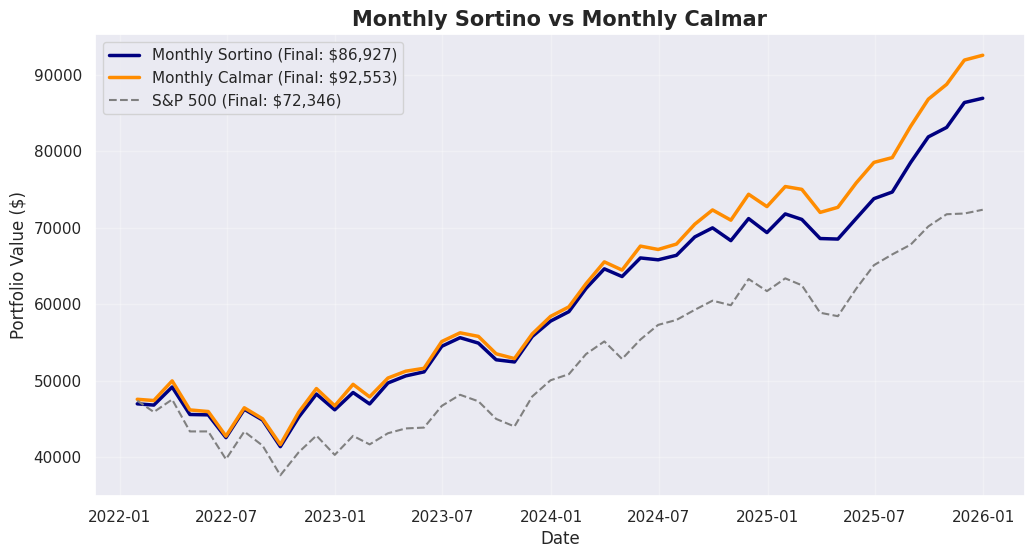

,Expected Return (Ann),Volatility (Ann),Sharpe Ratio,Max Drawdown,Avg Drawdown,VaR 95%,CVaR 95%,Skewness,Kurtosis,Total Return 2022-2025
Monthly Sortino,14.91%,14.31%,0.90,-15.87%,-4.83%,-6.38%,-7.20%,-0.33,-0.51,73.85%
Monthly Calmar,16.54%,14.63%,0.99,-16.68%,-4.90%,-6.27%,-7.37%,-0.32,-0.51,85.11%
S&P 500 (Monthly),10.52%,15.92%,0.54,-20.85%,-7.85%,-7.52%,-8.84%,-0.40,-0.48,44.69%


In [ ]:
# Calculate Final Metrics Function
def calc_monthly_metrics(returns_series, name):
    exp_ret = returns_series.mean() * trading_days_m
    vol = returns_series.std() * np.sqrt(trading_days_m)
    sharpe = (exp_ret - RISK_FREE_RATE) / vol
    cum_prod = (1 + returns_series).cumprod()
    max_dd = compute_drawdowns(cum_prod).min()
    avg_dd = compute_drawdowns(cum_prod)[compute_drawdowns(cum_prod) < 0].mean()

    return {
        'Expected Return (Ann)': exp_ret,
        'Volatility (Ann)': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Avg Drawdown': avg_dd,
        'VaR 95%': historical_var(returns_series, 0.95),
        'CVaR 95%': historical_cvar(returns_series, 0.95),
        'Skewness': skew(returns_series),
        'Kurtosis': kurtosis(returns_series),
        'Total Return 2022-2025': (cum_prod.iloc[-1] - 1)
    }

final_comparison = pd.DataFrame({
    'Monthly Sortino': calc_monthly_metrics(port_test_ret_sortino, 'Sortino'),
    'Monthly Calmar': calc_monthly_metrics(port_test_ret_calmar, 'Calmar'),
    'S&P 500 (Monthly)': calc_monthly_metrics(bench_test_ret_m, 'Benchmark')
}).T

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(cum_sortino_dollars.index, cum_sortino_dollars, label=f'Monthly Sortino (Final: ${cum_sortino_dollars.iloc[-1]:,.0f})', linewidth=2.5, color='navy')
plt.plot(cum_calmar_dollars.index, cum_calmar_dollars, label=f'Monthly Calmar (Final: ${cum_calmar_dollars.iloc[-1]:,.0f})', linewidth=2.5, color='darkorange')
plt.plot(cum_bench_dollars.index, cum_bench_dollars, label=f'S&P 500 (Final: ${cum_bench_dollars.iloc[-1]:,.0f})', linewidth=1.5, linestyle='--', color='gray')

plt.title(f"Monthly Sortino vs Monthly Calmar", fontsize=15, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

display(final_comparison.style.format({
    'Expected Return (Ann)': '{:.2%}',
    'Volatility (Ann)': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Max Drawdown': '{:.2%}',
    'Avg Drawdown': '{:.2%}',
    'VaR 95%': '{:.2%}',
    'CVaR 95%': '{:.2%}',
    'Skewness': '{:.2f}',
    'Kurtosis': '{:.2f}',
    'Total Return 2022-2025': '{:.2%}'
}))

*   **Return performance**: The Monthly Calmar strategy achieved a 85.11% Total Return over the 2022-2025 period. It beat the Monthly Sortino strategy by nearly 12% and the S&P 500 benchmark (44.69%).

*   **Volatility**: While the Calmar portfolio has a tiny higher volatility than the Sortino portfolio (14.31%  vs. 14.63%), it was rewarded with higher profits. This resulted in a Sharpe Ratio of 0.99, the highest risk-adjusted performance recorded in this entire study.

*   **Drawdown and Tail Risk**: Both the Sortino and Calmar portfolios proved their defensive capabilities against the benchmark. While the S&P 500 suffered a -20.85% maximum drawdown, both of our optimized portfolios kept drawdowns contained to the -16% range. Interestingly, the Calmar portfolio also exhibited the safest worst-case scenario metric, with a Monthly VaR of -6.27%.

In [ ]:
# Comparison dataframe
name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

# Create a union of all tickers selected by both methods to ensure none are missing
all_selected_m = sorted(list(set(best_sortino_tickers) | set(best_calmar_tickers)))

weights_comparison_m = pd.DataFrame({
    'Company': [name_mapping.get(t, t) for t in all_selected_m],
    'Sortino Portfolio (%)': pd.Series(weights_sortino * 100, index=all_selected_m),
    'Calmar Portfolio (%)': pd.Series(weights_calmar * 100, index=all_selected_m)
}, index=all_selected_m).fillna(0)

# Filter to show only assets that have weight in at least one of the two portfolios
weights_comparison_m = weights_comparison_m[weights_comparison_m[['Sortino Portfolio (%)', 'Calmar Portfolio (%)']].sum(axis=1) > 0]

display(weights_comparison_m.round(2).sort_values(by='Sortino Portfolio (%)', ascending=False))

# Summary of differences
diff_tickers = set(best_sortino_tickers).symmetric_difference(set(best_calmar_tickers))
print(f"\nNumber of assets that differ between the two picks: {len(diff_tickers)}")
if diff_tickers:
    print(f"Differing Tickers: {', '.join(sorted(list(diff_tickers)))}")

,Company,Sortino Portfolio (%),Calmar Portfolio (%)
NEE,NEXTERA_ENERGY,6.33,6.68
WMT,WALMART,5.80,6.04
LLY,ELI_LILLY,5.67,5.68
FNV,FRANCO_NEVADA,5.25,5.57
MCD,MCDONALDS,4.71,4.81
PEP,PEPSICO,4.39,0.00
WM,WASTE_MANAGEMENT,4.31,0.00
NOC,NORTHROP_GRUMMAN,3.98,0.00
MRK,MERCK,3.91,3.92
NKE,NIKE,3.78,3.89



Number of assets that differ between the two picks: 14
Differing Tickers: ADBE, ASML, COST, DE, IEF, JNJ, LMT, NOC, PEP, SMH, TLT, UNP, V, WM


In [ ]:
# Total return of each stock
bench_tot_return_m = (1 + bench_test_ret_m).cumprod().iloc[-1] - 1
stock_tot_returns_m = (1 + simple_test_returns_m).cumprod().iloc[-1] - 1

all_selected_tickers = list(set(best_sortino_tickers) | set(best_calmar_tickers))

# Align the weights
w_sortino = pd.Series(weights_sortino, index=best_sortino_tickers).reindex(all_selected_tickers).fillna(0)
w_calmar = pd.Series(weights_calmar, index=best_calmar_tickers).reindex(all_selected_tickers).fillna(0)

# Dollar Profits based on a $50,000 initial investment
profit_sortino_dollars = (w_sortino * total_investment) * stock_tot_returns_m[all_selected_tickers]
profit_calmar_dollars = (w_calmar * total_investment) * stock_tot_returns_m[all_selected_tickers]

name_mapping = results_df_train.set_index('Ticker')['Company'].to_dict()

# DataFrame
stock_df_m = pd.DataFrame({
    'Company': [name_mapping.get(t, t) for t in all_selected_tickers],
    'Stock Return (%)': stock_tot_returns_m[all_selected_tickers] * 100,
    'vs. S&P 500 (%)': (stock_tot_returns_m[all_selected_tickers] - bench_tot_return_m) * 100,
    'Sortino Wgt (%)': w_sortino * 100,
    'Sortino Profit ($)': profit_sortino_dollars,
    'Calmar Wgt (%)': w_calmar * 100,
    'Calmar Profit ($)': profit_calmar_dollars,
    'Calmar Edge ($)': profit_calmar_dollars - profit_sortino_dollars
}, index=all_selected_tickers)

# Sort by Calmar's Dollar Profit (descending)
stock_df_m = stock_df_m.sort_values(by='Calmar Profit ($)', ascending=False)

print(f"--- FINAL P&L SUMMARY: SORTINO vs CALMAR (Initial: ${total_investment:,.2f}) ---")
print(f"Total Profit (Monthly Calmar)  : ${profit_calmar_dollars.sum():,.2f}")
print(f"Total Profit (Monthly Sortino) : ${profit_sortino_dollars.sum():,.2f}")
print(f"Total Profit (S&P 500)         : ${(total_investment * bench_tot_return_m):,.2f}")
print("-" * 65)

# Colour style function
def color_negative_red(val):
    color = 'red' if val < 0 else 'green'
    return f'color: {color}'

print("(Sorted by Monthly Calmar Profit descending)")

# Display all rows
stock_colour_m = stock_df_m.style.format({
    'Stock Return (%)': '{:.2f}%',
    'vs. S&P 500 (%)': '{:+.2f}%',
    'Sortino Wgt (%)': '{:.2f}%',
    'Sortino Profit ($)': '${:,.2f}',
    'Calmar Wgt (%)': '{:.2f}%',
    'Calmar Profit ($)': '${:,.2f}',
    'Calmar Edge ($)': '${:+,.2f}'
}).map(color_negative_red, subset=['vs. S&P 500 (%)', 'Sortino Profit ($)', 'Calmar Profit ($)', 'Calmar Edge ($)'])

display(stock_colour_m)

--- FINAL P&L SUMMARY: SORTINO vs CALMAR (Initial: $50,000.00) ---
Total Profit (Monthly Calmar)  : $47,399.79
Total Profit (Monthly Sortino) : $43,002.20
Total Profit (S&P 500)         : $22,345.57
-----------------------------------------------------------------
(Sorted by Monthly Calmar Profit descending)


,Company,Stock Return (%),vs. S&P 500 (%),Sortino Wgt (%),Sortino Profit ($),Calmar Wgt (%),Calmar Profit ($),Calmar Edge ($)
LLY,ELI_LILLY,305.77%,+261.08%,5.67%,"$8,675.18",5.68%,"$8,684.33",$+9.15
AVGO,BROADCOM,467.59%,+422.89%,2.59%,"$6,065.91",2.57%,"$6,002.86",$-63.05
GE,GENERAL ELECTRIC,440.22%,+395.52%,2.57%,"$5,648.09",2.67%,"$5,880.52",$+232.43
WMT,WALMART,144.48%,+99.79%,5.80%,"$4,188.76",6.04%,"$4,364.03",$+175.28
CCJ,CAMECO,323.02%,+278.33%,2.65%,"$4,282.49",2.69%,"$4,337.03",$+54.54
NVDA,NVIDIA,538.89%,+494.20%,1.61%,"$4,343.51",1.61%,"$4,332.27",$-11.24
GOOGL,ALPHABET,118.31%,+73.62%,2.82%,"$1,667.39",2.88%,"$1,701.54",$+34.15
FNV,FRANCO_NEVADA,56.24%,+11.55%,5.25%,"$1,475.41",5.57%,"$1,565.08",$+89.67
SMH,SEMICONDUCTORS_ETF,141.23%,+96.54%,0.00%,$0.00,2.21%,"$1,560.39","$+1,560.39"
JPM,JPMORGAN_CHASE,126.85%,+82.16%,2.29%,"$1,454.79",2.33%,"$1,480.44",$+25.65


By analyzing the individual Profit and Loss of each asset, we can pinpoint why the Monthly Calmar strategy outperformed the Monthly Sortino strategy. While both strategies utilized high-performers like Eli Lilly (LLY) and General Electric (GE), the Calmar strategy came from three specific situations:


*   Semiconductors ETF (SMH): Calmar Edge: +\$1,560.39. Calmar ratio recognized that while individual chip stocks are volatile, the semiconductor sector as a whole had resilient historical drawdowns. By assigning a 2.21% weight to SMH (Sortino strategy missed entirely).
*   Visa (V), Costco (COST), Lockheed Martin (LMT). Because the Calmar ratio focuses on Maximum Drawdown, it gave them roughly 3% to 3.5% weight each, generating nearly \$2,900 in additional profit that the Sortino portfolio did not participate in.

*   Adobe (ADBE), Pepsi (PEP): Calmar did not lose money on these companies by avoiding them. The Sortino strategy allocated capital in those and losing \$452.58 and \$130.00 respectively on those trades.


